# Timing Plots

Light report-style timing plots for the current CSV layout:

- `Results/timing_results/CSVs/M1`
- `Results/timing_results/CSVs/M2`
- `Results/timing_results/CSVs/Old`

Set `MACHINE = "M1"` or `MACHINE = "M2"`, then run all cells. M1 includes `optimized_for_cache`; M2 includes the baseline C++ data.


In [156]:
from pathlib import Path
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator

# Choose the machine dataset to plot.
MACHINE = "M1"  # "M1" or "M2"

BASE = Path.cwd().resolve()
while not ((BASE / "Results").exists() and (BASE / "Code").exists()):
    if BASE.parent == BASE:
        raise RuntimeError("Could not find team80 repository root")
    BASE = BASE.parent

CSV_ROOT = BASE / "Results" / "timing_results" / "CSVs"
PLOT_DIR = BASE / "Results" / "timing_results" / "Plots" / "comparison_plots" / MACHINE
PLOT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "Baseline C++": "#48c7ff",
    "Optimized C++": "#39d12f",
    "Optimized-for-cache C++": "#ffd166",
    "Python": "#ff7a1a",
    "SIMD C++": "#b02ac8",
    "SIMD cache-packed C++": "#b02ac8",
}

KERNEL_COLORS = {
    "equi_linear": "#ff5555",
    "geometric_product": "#48c7ff",
    "equi_join": "#b892ff",
    "equi_rms_norm": "#4cff74",
    "scaler_gated_gelu": "#ffb75e",
    "equi_geometric_attention": "#e6e65c",
}

STYLE = {
    "figure.facecolor": "white",
    "axes.facecolor": "#e3e3e3",
    "axes.edgecolor": "#000000",
    "axes.labelcolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "text.color": "#000000",
    "grid.color": "white",
    "legend.facecolor": "white",
    "legend.edgecolor": "#cccccc",
    "font.family": "DejaVu Sans",
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
}
plt.rcParams.update(STYLE)

CSV_PATHS = {
    "M1": {
        "end_to_end": {
            "Baseline C++": CSV_ROOT / "M1/end_to_end/c_timing_results_2026-05-29_12-17-11.csv",
            "Python": CSV_ROOT / "M1/end_to_end/python_timing_results_2026-05-30_13-27-38.csv",
            "Optimized C++": CSV_ROOT / "Old/2026-05-30/optimized_c_timing_results_2026-05-30_16-52-09.csv",
            "Optimized-for-cache C++": CSV_ROOT / "M1/end_to_end/optimized_for_cache_c_timing_results_2026-05-30_15-06-18.csv",
            "SIMD C++": CSV_ROOT / "M1/end_to_end/simd_c_timing_results_2026-05-31_17-05-27.csv",
        },
        "per_kernel": {
            "Baseline C++": CSV_ROOT / "M1/per_kernel/baseline_c_per_kernel_seconds_results_2026-06-01_08-01-50.csv",
            "Python": CSV_ROOT / "M1/per_kernel/python_per_kernel_seconds_results_2026-06-01_08-57-17.csv",
            "SIMD C++": CSV_ROOT / "M1/per_kernel/simd_c_per_kernel_seconds_results_2026-06-01_08-35-31.csv",
            "Optimized-for-cache C++": CSV_ROOT / "M1/per_kernel/optimized_for_cache_c_per_kernel_seconds_results_2026-06-01_08-48-04.csv",
        },
    },
    "M2": {
        "end_to_end": {
            "Baseline C++": CSV_ROOT / "M2/baseline_final/c_timing_results_2026-05-25_22-17-15.csv",
            "Python": CSV_ROOT / "M2/final/python_timing_results_2026-05-30_20-11-29.csv",
            "Optimized C++": CSV_ROOT / "M2/final/optimized_c_timing_results_2026-05-30_20-20-13.csv",
            "SIMD C++": CSV_ROOT / "M2/final/simd_c_timing_results_2026-05-30_22-54-00.csv",
        },
        "per_kernel": {
            "Baseline C++": CSV_ROOT / "M2/2026-05-30/baseline_c_per_kernel_seconds_results_2026-05-30_23-39-07.csv",
            "Python": CSV_ROOT / "M2/2026-05-30/python_per_kernel_seconds_results_2026-05-30_23-57-04.csv",
            "Optimized C++": CSV_ROOT / "M2/2026-05-30/optimized_c_per_kernel_seconds_results_2026-05-30_23-19-55.csv",
            "SIMD C++": CSV_ROOT / "M2/2026-05-30/simd_c_per_kernel_seconds_results_2026-05-30_23-50-58.csv",
        },
    },
}

print(f"Repository: {BASE}")
print(f"Machine: {MACHINE}")
print(f"Output: {PLOT_DIR}")


Repository: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80
Machine: M1
Output: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1


## Load CSVs


In [157]:
DEFAULT_COLUMNS = ["implementation", "batch", "tokens", "channels", "layers", "avg_ms", "min_ms", "max_ms"]
BASELINE_COLUMNS_NO_L = ["implementation", "batch", "tokens", "channels", "avg_ms", "min_ms", "max_ms"]

def normalize_col(name):
    return str(name).strip().lower().replace(" ", "_").replace("-", "_")

def infer_layers(df):
    if "layers" not in df.columns:
        # Older end-to-end baseline CSVs used N = channels = layers.
        df["layers"] = df["channels"]
    return df

def load_csv(path, label, kind):
    path = Path(path)
    if not path.exists():
        print(f"Skipping missing {kind} CSV for {label}: {path}")
        return pd.DataFrame()

    df = pd.read_csv(path)
    df.columns = [normalize_col(c) for c in df.columns]

    expected = {"batch", "tokens", "channels", "avg_ms"}
    if not expected.issubset(df.columns):
        raw = pd.read_csv(path, header=None)
        if raw.shape[1] == len(DEFAULT_COLUMNS):
            raw.columns = DEFAULT_COLUMNS
        elif raw.shape[1] == len(BASELINE_COLUMNS_NO_L):
            raw.columns = BASELINE_COLUMNS_NO_L
        else:
            raise ValueError(f"Unsupported CSV shape for {path}: {raw.shape}")
        df = raw
        df.columns = [normalize_col(c) for c in df.columns]

    rename = {"b": "batch", "t": "tokens", "c": "channels", "l": "layers"}
    df = df.rename(columns={c: rename.get(c, c) for c in df.columns})
    df = infer_layers(df)

    required = ["batch", "tokens", "channels", "layers", "avg_ms"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path} missing columns {missing}; has {list(df.columns)}")

    for col in ["batch", "tokens", "channels", "layers", "avg_ms", "min_ms", "max_ms"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=required).copy()
    for col in ["batch", "tokens", "channels", "layers"]:
        df[col] = df[col].astype(int)

    df["label"] = label
    df["kind"] = kind
    df["n"] = df["channels"]
    df["config"] = df.apply(lambda r: f"N={r['n']}  B={r['batch']} T={r['tokens']} C={r['channels']} L={r['layers']}", axis=1)
    return df

def load_group(machine, kind):
    frames = []
    for label, path in CSV_PATHS[machine][kind].items():
        frame = load_csv(path, label, kind)
        if not frame.empty:
            frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

end_to_end = load_group(MACHINE, "end_to_end")
per_kernel = load_group(MACHINE, "per_kernel")

print("End-to-end rows")
display(end_to_end.groupby("label")["avg_ms"].agg(["count", "min", "max"]))
print("Per-kernel rows")
display(per_kernel.groupby(["label", "kernel"])["avg_ms"].agg(["count", "min", "max"]))


Skipping missing end_to_end CSV for Optimized C++: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/CSVs/Old/2026-05-30/optimized_c_timing_results_2026-05-30_16-52-09.csv
End-to-end rows


,count,min,max
label,,,
Baseline C++,6,988.479838,1.006918e+06
Optimized-for-cache C++,7,1.397828,1.411384e+04
Python,7,2.939018,1.008019e+04
SIMD C++,7,0.656672,5.865452e+03


Per-kernel rows


count       min  \
label                   kernel                                      
Baseline C++            equi_geometric_attention      7  0.120144   
                        equi_join                     7  2.239360   
                        equi_linear                   7  0.041856   
                        equi_rms_norm                 7  0.000560   
                        geometric_product             7  0.087117   
                        scaler_gated_gelu             7  0.000801   
Optimized-for-cache C++ equi_geometric_attention      7  0.034290   
                        equi_join                     7  0.003650   
                        equi_linear                   7  0.001122   
                        equi_rms_norm                 7  0.001299   
                        geometric_product             7  0.001907   
                        scaler_gated_gelu             7  0.001265   
Python                  equi_geometric_attention      7  0.397164   
                        equi_join                     7  0.103355   
                        equi_linear                   7  0.116762   
                        equi_rms_norm                 7  0.025307   
                        geometric_product             7  0.109781   
                        scaler_gated_gelu             7  0.005885   
SIMD C++                equi_geometric_attention      7  0.016371   
                        equi_join                     7  0.001471   
                        equi_linear                   7  0.000489   
                        equi_rms_norm                 7  0.000453   
                        geometric_product             7  0.000574   
                        scaler_gated_gelu             7  0.000469   

                                                           max  
label                   kernel                                  
Baseline C++            equi_geometric_attention    553.810129  
                        equi_join                   240.888101  
                        equi_linear               12435.873601  
                        equi_rms_norm                 0.341475  
                        geometric_product           215.632944  
                        scaler_gated_gelu             0.939612  
Optimized-for-cache C++ equi_geometric_attention    146.663839  
                        equi_join                     1.189055  
                        equi_linear                  13.971328  
                        equi_rms_norm                 0.347779  
                        geometric_product             1.339810  
                        scaler_gated_gelu             0.914047  
Python                  equi_geometric_attention     26.612542  
                        equi_join                     7.045561  
                        equi_linear                  19.425525  
                        equi_rms_norm                 1.365380  
                        geometric_product             7.552147  
                        scaler_gated_gelu             0.148651  
SIMD C++                equi_geometric_attention     69.848645  
                        equi_join                     0.932726  
                        equi_linear                   5.229213  
                        equi_rms_norm                 0.181672  
                        geometric_product             0.781675  
                        scaler_gated_gelu             0.677574

## Plot helpers


In [158]:
def ms_formatter(x, pos):
    return f"{x:g} ms"

def perf_formatter(x, pos):
    return f"{x:g}"

def setup_axis(ax):
    ax.set_facecolor("#e3e3e3")
    ax.grid(True, which="major", axis="y", color="white", linestyle="-", linewidth=1.2, alpha=1.0)
    ax.grid(False, axis="x")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#000000")
    ax.spines["bottom"].set_linewidth(1.1)
    ax.tick_params(colors="#000000")
    return ax

PLOT_SUBDIRS = {
    "end_to_end": PLOT_DIR / "end_to_end",
    "per_kernel": PLOT_DIR / "per_kernel",
    "speedups": PLOT_DIR / "speedups",
}
for subdir in PLOT_SUBDIRS.values():
    subdir.mkdir(parents=True, exist_ok=True)


def plot_output_dir(name):
    if name.startswith("end_to_end"):
        return PLOT_SUBDIRS["end_to_end"]
    if name.startswith("kernel_"):
        return PLOT_SUBDIRS["per_kernel"]
    if "per_kernel_speedup" in name or "end_to_end_speedup" in name or "_vs_" in name or name.startswith("top_"):
        return PLOT_SUBDIRS["speedups"]
    return PLOT_DIR


def savefig(fig, name):
    out_dir = plot_output_dir(name)
    out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / name
    fig.savefig(out, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out}")
    return out

def pivot_runtime(df):
    return (
        df.pivot_table(index=["n", "batch", "tokens", "channels", "layers"], columns="label", values="avg_ms", aggfunc="mean")
        .reset_index()
        .sort_values("n")
    )


## Report-style Runtime Plots

Creates light grey, line-and-marker plots for the end-to-end implementation comparison and the compiler flag sweep.


Flag sweep CSV: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/CSVs/M1/flag_sweep_2026-06-20/optimized_vs_simd_flag_sweep_2026-06-20_00-30-22.csv
Flag sweep/report-style plots: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/flag_sweeps
Missing line: Optimized C++
Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/flag_sweeps/end_to_end_optimized_cache_simd_python_report_style_gflops_per_second.png


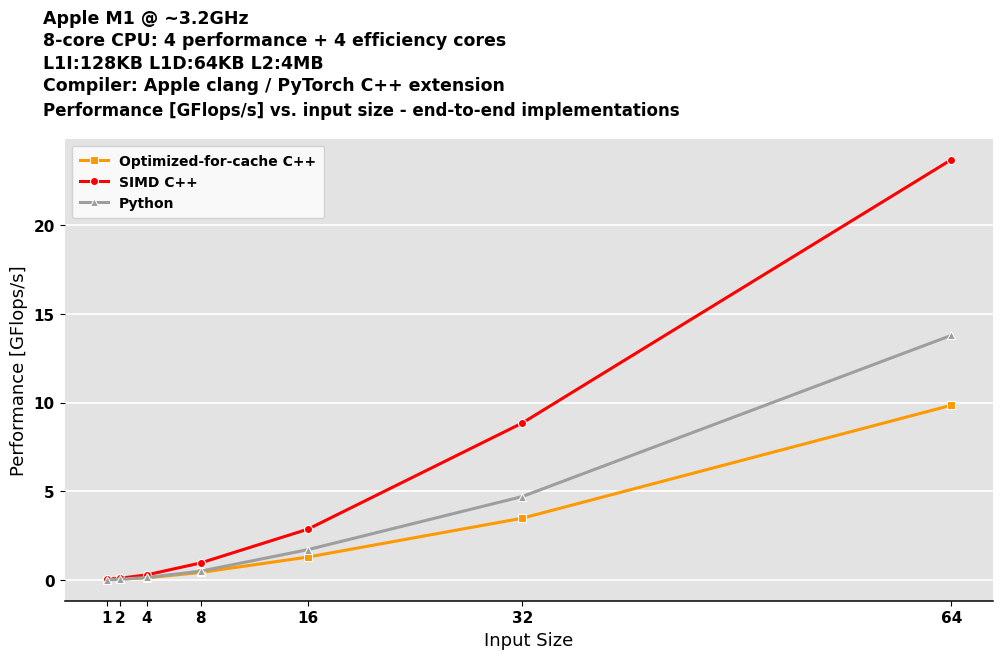

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/flag_sweeps/simd_cpp_flag_sweep_speedup_vs_default.png


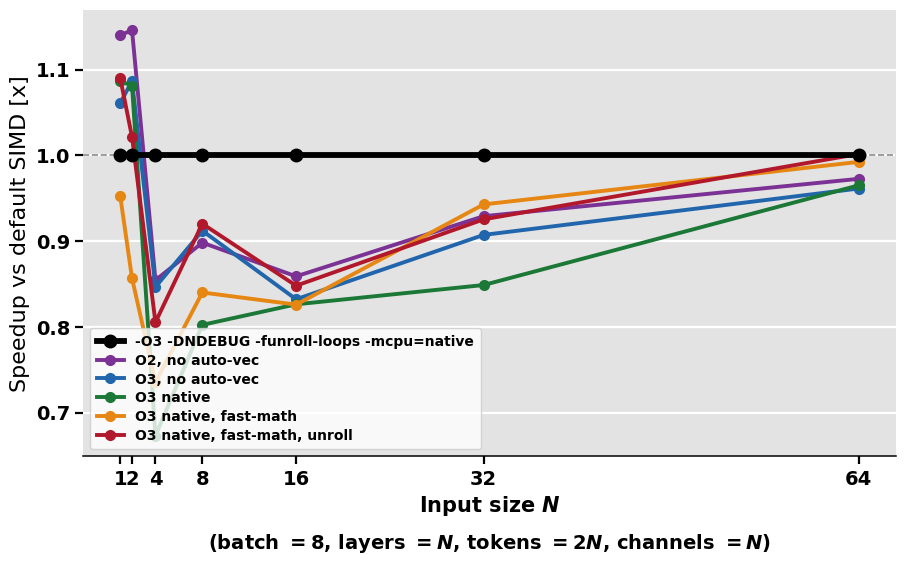

In [159]:
REPORT_PLOT_DIR = BASE / "Results" / "timing_results" / "Plots" / "comparison_plots" / MACHINE / "flag_sweeps"
REPORT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

FLOP_TOOLS_DIR = BASE / "Code" / "python" / "tools"
if str(FLOP_TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(FLOP_TOOLS_DIR))

from cpp_flop_counter import (
    Build,
    EquiGeometricAttentionCfg,
    EquiJoinCfg,
    EquiLinearCfg,
    EquiRMSNormCfg,
    GeometricProductCfg,
    OpWeights,
    ScalerGatedGeluCfg,
    equi_geometric_attention_count,
    equi_join_count,
    equi_linear_count,
    equi_rms_norm_count,
    geometric_product_count,
    scaler_gated_gelu_count,
)

# macOS does not expose a stable frequency through sysctl on this machine.
# GFlops/s: billions of weighted FLOPs divided by elapsed seconds.
M1_INFO_LINES = [
    "Apple M1 @ ~3.2GHz",
    "8-core CPU: 4 performance + 4 efficiency cores",
    "L1I:128KB L1D:64KB L2:4MB",
    "Compiler: Apple clang / PyTorch C++ extension",
]

REPORT_COLORS = {
    "Python": "#9e9e9e",
    "Optimized C++": "#008000",
    "Optimized-for-cache C++": "#ff9900",
    "SIMD C++": "#ff0000",
    "default": "#000000",
    "default_simd": "#000000",
    "o2_no_autovec": "#7b3294",
    "o3_no_autovec": "#2166ac",
    "o3_native": "#1b7837",
    "o3_native_fast_math": "#e68613",
    "o3_native_fast_math_unroll": "#b2182b",
}

REPORT_MARKERS = {
    "Python": "^",
    "Optimized C++": "o",
    "Optimized-for-cache C++": "s",
    "SIMD C++": "o",
    "default": "o",
    "default_simd": "o",
    "o2_no_autovec": "o",
    "o3_no_autovec": "o",
    "o3_native": "o",
    "o3_native_fast_math": "o",
    "o3_native_fast_math_unroll": "o",
}

DEFAULT_FLAGS = {
    "Optimized C++": "-std=c++17 -O3 -DNDEBUG -funroll-loops -fno-tree-vectorize -fno-slp-vectorize -Wno-error=invalid-specialization -Wno-invalid-specialization -mcpu=native",
    "SIMD C++": "-std=c++17 -O3 -DNDEBUG -funroll-loops -Wno-error=invalid-specialization -Wno-invalid-specialization -mcpu=native",
}

FLAG_DISPLAY_NAMES = {
    "default": "Default (setup.py flags)",
    "default_simd": "-O3 -DNDEBUG -funroll-loops -mcpu=native",
    "o2_no_autovec": "O2, no auto-vec",
    "o3_no_autovec": "O3, no auto-vec",
    "o3_native": "O3 native",
    "o3_native_fast_math": "O3 native, fast-math",
    "o3_native_fast_math_unroll": "O3 native, fast-math, unroll",
}

# Use one shared FLOP model for plotted performance comparisons.
# If each implementation is credited with its own executed FLOPs, dense/reference
# Python can look artificially efficient because it gets a much larger FLOP count.
COMMON_PERFORMANCE_BUILD = Build.OPTIMIZED
USE_COMMON_PERFORMANCE_FLOPS = True

BUILD_FOR_LABEL = {
    "Python": Build.BASELINE,
    "Baseline C++": Build.BASELINE,
    "Optimized C++": Build.OPTIMIZED,
    "Optimized-for-cache C++": Build.OPTIMIZED,
    "SIMD C++": Build.SIMD,
}


def performance_build_for_label(impl_label):
    if USE_COMMON_PERFORMANCE_FLOPS:
        return COMMON_PERFORMANCE_BUILD
    return BUILD_FOR_LABEL.get(impl_label, Build.OPTIMIZED)


FLAG_SWEEP_DIR = CSV_ROOT / "M1" / "flag_sweep_2026-06-20"


def latest_flag_sweep_file():
    files = sorted(FLAG_SWEEP_DIR.glob("optimized_vs_simd_flag_sweep_*.csv"))
    if not files:
        raise FileNotFoundError(f"No flag sweep CSVs found under {FLAG_SWEEP_DIR}")
    return files[-1]


FLAG_SWEEP_FILE = latest_flag_sweep_file()
print(f"Flag sweep CSV: {FLAG_SWEEP_FILE}")
print(f"Flag sweep/report-style plots: {REPORT_PLOT_DIR}")


def report_safe_label(label):
    return label.lower().replace(" ", "_").replace("+", "p").replace("-", "_")


def wrap_flags(flags, width=62):
    words = flags.split()
    lines = []
    line = ""
    for word in words:
        candidate = f"{line} {word}".strip()
        if len(candidate) > width and line:
            lines.append(line)
            line = word
        else:
            line = candidate
    if line:
        lines.append(line)
    return "\n".join(lines)


def flag_legend_label(flag_id, impl_label=None):
    if flag_id != "default":
        return FLAG_DISPLAY_NAMES.get(flag_id, flag_id)
    flags = DEFAULT_FLAGS.get(impl_label, "setup.py default flags")
    return f"Default ({wrap_flags(flags, width=48)})"


def weighted_full_model_flops(batch, tokens, channels, layers, impl_label):
    build = performance_build_for_label(impl_label)
    weights = OpWeights()
    layer_flops = 0.0
    layer_flops += equi_linear_count(
        EquiLinearCfg(batch=batch, tokens=tokens, channels_in=channels, channels_out=channels, bias=True, build=build)
    ).weighted_flops(weights)
    layer_flops += geometric_product_count(
        GeometricProductCfg(m=batch * tokens * channels, build=build)
    ).weighted_flops(weights)
    layer_flops += equi_join_count(
        EquiJoinCfg(m=batch * tokens * channels, reference=True, x_nnz_frac=1.0, include_kernel_build=False, noCompOpt=True, build=build)
    ).weighted_flops(weights)
    layer_flops += equi_rms_norm_count(
        EquiRMSNormCfg(n=batch * tokens, channels=channels, hasWt=True, mOne=False, build=build)
    ).weighted_flops(weights)
    layer_flops += scaler_gated_gelu_count(
        ScalerGatedGeluCfg(m=batch * tokens * channels, build=build)
    ).weighted_flops(weights)
    layer_flops += equi_geometric_attention_count(
        EquiGeometricAttentionCfg(
            batch=batch,
            heads=4,
            t_query=tokens,
            t_key=tokens,
            channels_qk=channels,
            channels_v=channels,
            kinds=["ipa", "daa"],
            is_causal=True,
            build=build,
        )
    ).weighted_flops(weights)
    return layer_flops * layers


def add_gflops_per_second(df):
    df = df.copy()
    if "label" not in df.columns and "implementation" in df.columns:
        df["label"] = df["implementation"]
    df["weighted_flops"] = df.apply(
        lambda r: weighted_full_model_flops(
            int(r["batch"]), int(r["tokens"]), int(r["channels"]), int(r["layers"]), r["label"]
        ),
        axis=1,
    )
    seconds = df["avg_ms"] / 1000.0
    df["gflops_per_second"] = (df["weighted_flops"] / 1e9) / seconds
    return df


def weighted_kernel_flops(kernel, batch, tokens, channels, impl_label):
    build = performance_build_for_label(impl_label)
    weights = OpWeights()
    if kernel == "geometric_product":
        tally = geometric_product_count(GeometricProductCfg(m=batch * tokens * channels, build=build))
    elif kernel == "equi_linear":
        tally = equi_linear_count(
            EquiLinearCfg(batch=batch, tokens=tokens, channels_in=channels, channels_out=channels, bias=True, build=build)
        )
    elif kernel == "equi_join":
        tally = equi_join_count(
            EquiJoinCfg(m=batch * tokens * channels, reference=True, x_nnz_frac=1.0, include_kernel_build=False, noCompOpt=True, build=build)
        )
    elif kernel == "equi_rms_norm":
        tally = equi_rms_norm_count(
            EquiRMSNormCfg(n=batch * tokens, channels=channels, hasWt=True, mOne=False, build=build)
        )
    elif kernel == "scaler_gated_gelu":
        tally = scaler_gated_gelu_count(ScalerGatedGeluCfg(m=batch * tokens * channels, build=build))
    elif kernel == "equi_geometric_attention":
        tally = equi_geometric_attention_count(
            EquiGeometricAttentionCfg(
                batch=batch,
                heads=4,
                t_query=tokens,
                t_key=tokens,
                channels_qk=channels,
                channels_v=channels,
                kinds=["ipa", "daa"],
                is_causal=True,
                build=build,
            )
        )
    else:
        raise ValueError(f"Unknown kernel for FLOP conversion: {kernel}")
    return tally.weighted_flops(weights)


def add_kernel_gflops_per_second(df):
    df = df.copy()
    df["weighted_flops"] = df.apply(
        lambda r: weighted_kernel_flops(
            r["kernel"], int(r["batch"]), int(r["tokens"]), int(r["channels"]), r["label"]
        ),
        axis=1,
    )
    seconds = df["avg_ms"] / 1000.0
    df["gflops_per_second"] = (df["weighted_flops"] / 1e9) / seconds
    return df


def report_axis(ax):
    ax.set_facecolor("#e3e3e3")
    ax.grid(True, axis="y", color="white", linewidth=1.2)
    ax.grid(False, axis="x")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#000000")
    ax.spines["bottom"].set_linewidth(1.1)
    ax.tick_params(colors="#000000", labelsize=11)
    ax.xaxis.label.set_color("#000000")
    ax.yaxis.label.set_color("#000000")
    ax.title.set_color("#000000")
    return ax


def add_report_header(fig, subtitle):
    top = 0.965
    for i, line in enumerate(M1_INFO_LINES):
        fig.text(0.06, top - i * 0.032, line, ha="left", va="top", fontsize=12.5, fontweight="bold", color="#000000")
    fig.text(0.06, top - len(M1_INFO_LINES) * 0.032 - 0.004, subtitle, ha="left", va="top", fontsize=12, color="#000000")


def save_report_fig(fig, name):
    out = REPORT_PLOT_DIR / name
    fig.savefig(out, dpi=240, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out}")
    return out


def plot_report_lines(df, series_col, series_order, title_suffix, filename, legend_right=False):
    df = add_gflops_per_second(df)
    fig = plt.figure(figsize=(11.2 if legend_right else 10.8, 7.0), facecolor="white")
    ax = fig.add_axes([0.08, 0.12, 0.86, 0.66])

    for series in series_order:
        part = df[df[series_col] == series].sort_values("n")
        if part.empty:
            print(f"Missing line: {series}")
            continue
        impl_for_default = part["label"].iloc[0] if "label" in part.columns else None
        label = flag_legend_label(series, impl_for_default) if series_col == "flag_id" else series
        ax.plot(
            part["n"],
            part["gflops_per_second"],
            marker=REPORT_MARKERS.get(series, REPORT_MARKERS.get(impl_for_default, "o")),
            markersize=5.8,
            linewidth=2.8 if series == "default" else 2.2,
            color=REPORT_COLORS.get(series, REPORT_COLORS.get(impl_for_default, "#000000")),
            markeredgecolor="white",
            markeredgewidth=0.75,
            label=label,
        )

    add_report_header(fig, f"Performance [GFlops/s] vs. input size - {title_suffix}")
    ax.set_xlabel("Input Size")
    ax.set_ylabel("Performance [GFlops/s]")
    ax.set_xticks(sorted(df["n"].unique()))
    ax.set_xticklabels([str(x) for x in sorted(df["n"].unique())])
    report_axis(ax)
    legend = ax.legend(
        loc="upper left",
        frameon=True,
        facecolor="white",
        edgecolor="#cccccc",
        fontsize=8 if legend_right else 10,
        labelspacing=0.45 if legend_right else 0.5,
        handlelength=1.8 if legend_right else 2.0,
        borderpad=0.55 if legend_right else 0.6,
    )
    for text in legend.get_texts():
        text.set_color("#000000")
    save_report_fig(fig, filename)
    plt.show()


def plot_report_end_to_end():
    labels = ["Optimized C++", "Optimized-for-cache C++", "SIMD C++", "Python"]
    df = end_to_end[end_to_end["label"].isin(labels)].copy()
    if df.empty:
        print("No end-to-end data available for report plot")
        return
    plot_report_lines(
        df,
        series_col="label",
        series_order=labels,
        title_suffix="end-to-end implementations",
        filename="end_to_end_optimized_cache_simd_python_report_style_gflops_per_second.png",
        legend_right=False,
    )


def load_flag_sweep():
    df = pd.read_csv(FLAG_SWEEP_FILE)
    df.columns = [normalize_col(c) for c in df.columns]
    for col in ["batch", "tokens", "channels", "layers", "avg_ms", "min_ms", "max_ms"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["implementation", "flag_id", "channels", "avg_ms"]).copy()
    for col in ["batch", "tokens", "channels", "layers"]:
        df[col] = df[col].astype(int)
    df["n"] = df["channels"]
    df["label"] = df["implementation"]
    return df


def load_default_flag_rows(impl_label):
    path = CSV_PATHS[MACHINE]["end_to_end"].get(impl_label)
    if path is None:
        print(f"No default CSV configured for {impl_label}")
        return pd.DataFrame()
    df = load_csv(path, impl_label, "default_flags")
    if df.empty:
        return df
    return pd.DataFrame({
        "implementation": impl_label,
        "label": impl_label,
        "flag_id": "default",
        "flags": DEFAULT_FLAGS.get(impl_label, "setup.py default flags"),
        "batch": df["batch"],
        "tokens": df["tokens"],
        "channels": df["channels"],
        "layers": df["layers"],
        "avg_ms": df["avg_ms"],
        "min_ms": df.get("min_ms"),
        "max_ms": df.get("max_ms"),
        "n": df["n"],
    })


SIMD_FLAG_ORDER = [
    "default_simd",
    "o2_no_autovec",
    "o3_no_autovec",
    "o3_native",
    "o3_native_fast_math",
    "o3_native_fast_math_unroll",
]


def add_simd_flag_sweep_speedup(df):
    """Compare compiler flags by speedup against default SIMD at the same N."""
    default = (
        df[df["flag_id"] == "default_simd"][["n", "avg_ms"]]
        .rename(columns={"avg_ms": "default_avg_ms"})
        .drop_duplicates("n")
    )
    if default.empty:
        raise ValueError("SIMD flag sweep needs default_simd rows for normalization")

    df = df.merge(default, on="n", how="left")
    if df["default_avg_ms"].isna().any():
        missing = sorted(df.loc[df["default_avg_ms"].isna(), "n"].unique())
        raise ValueError(f"Missing default_simd rows for N={missing}")

    df["speedup_vs_default"] = df["default_avg_ms"] / df["avg_ms"]
    return df


def plot_simd_flag_sweep_report():
    df = load_flag_sweep()
    df = df[(df["implementation"] == "SIMD C++") & (df["n"] <= 64)].copy()
    if df.empty:
        print("No SIMD flag sweep data available")
        return

    df = add_simd_flag_sweep_speedup(df)
    fig, ax = plt.subplots(figsize=(9.5, 6.2), facecolor="white")
    ax.set_facecolor("#e3e3e3")

    for flag_id in SIMD_FLAG_ORDER:
        part = df[df["flag_id"] == flag_id].sort_values("n")
        if part.empty:
            print(f"Missing line: {flag_id}")
            continue
        is_default = flag_id == "default_simd"
        ax.plot(
            part["n"],
            part["speedup_vs_default"],
            marker="o",
            markersize=9.0 if is_default else 7.0,
            linewidth=4.2 if is_default else 2.8,
            color=REPORT_COLORS.get(flag_id, "#000000"),
            markeredgecolor=REPORT_COLORS.get(flag_id, "#000000"),
            label=FLAG_DISPLAY_NAMES.get(flag_id, flag_id),
            zorder=3 if is_default else 2,
        )

    ax.axhline(1.0, color="#000000", linewidth=1.2, linestyle="--", alpha=0.45)
    ax.grid(True, axis="y", color="white", linewidth=1.6)
    ax.grid(False, axis="x")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#000000")
    ax.spines["bottom"].set_linewidth(1.1)

    n_values = sorted(df["n"].unique())
    ax.set_xticks(n_values)
    ax.set_xticklabels([str(n) for n in n_values], fontweight="bold")
    ax.tick_params(axis="both", colors="#000000", labelsize=14, width=1.6, length=6)
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

    ax.set_xlabel(r"Input size $\boldsymbol{N}$", fontsize=15, fontweight="bold", color="#000000")
    ax.set_ylabel("Speedup vs default SIMD [x]", fontsize=16, color="#000000")
    ax.text(
        0.5,
        -0.17,
        r"(batch $=8$, layers $=\boldsymbol{N}$, tokens $=2\boldsymbol{N}$, channels $=\boldsymbol{N}$)",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=14,
        color="#000000",
    )

    legend = ax.legend(
        loc="lower left",
        frameon=True,
        facecolor="white",
        edgecolor="#cccccc",
        fontsize=10,
        handlelength=2.0,
        borderpad=0.45,
        labelspacing=0.35,
    )
    for text in legend.get_texts():
        text.set_color("#000000")
        text.set_fontweight("bold")

    fig.subplots_adjust(left=0.13, right=0.985, bottom=0.24, top=0.96)
    save_report_fig(fig, "simd_cpp_flag_sweep_speedup_vs_default.png")
    plt.show()


def plot_report_flag_sweep(impl_label):
    if impl_label == "SIMD C++":
        plot_simd_flag_sweep_report()
        return

    sweep = load_flag_sweep()
    sweep = sweep[sweep["implementation"] == impl_label].copy()
    default_rows = load_default_flag_rows(impl_label)
    df = pd.concat([sweep, default_rows], ignore_index=True)
    if df.empty:
        print(f"No flag sweep data for {impl_label}")
        return

    order = [
        "default",
        "o2_no_autovec",
        "o3_no_autovec",
        "o3_native",
        "o3_native_fast_math",
        "o3_native_fast_math_unroll",
    ]
    plot_report_lines(
        df,
        series_col="flag_id",
        series_order=order,
        title_suffix=f"{impl_label} compiler flag sweep",
        filename=f"{report_safe_label(impl_label)}_flag_sweep_with_default_report_style_gflops_per_second.png",
        legend_right=True,
    )


plot_report_end_to_end()
plot_simd_flag_sweep_report()


## End-to-end timing comparison


Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/end_to_end/end_to_end_optimized_cache_simd_python.png


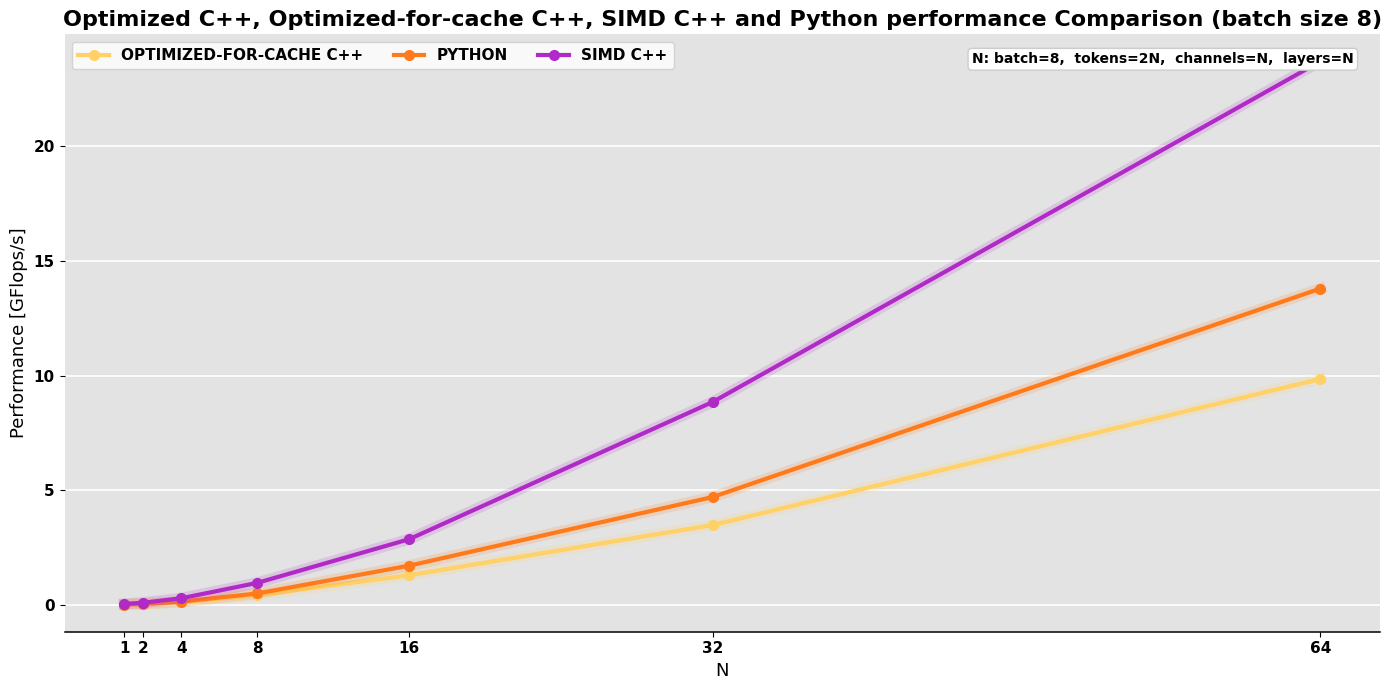

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/end_to_end/end_to_end_with_baseline.png


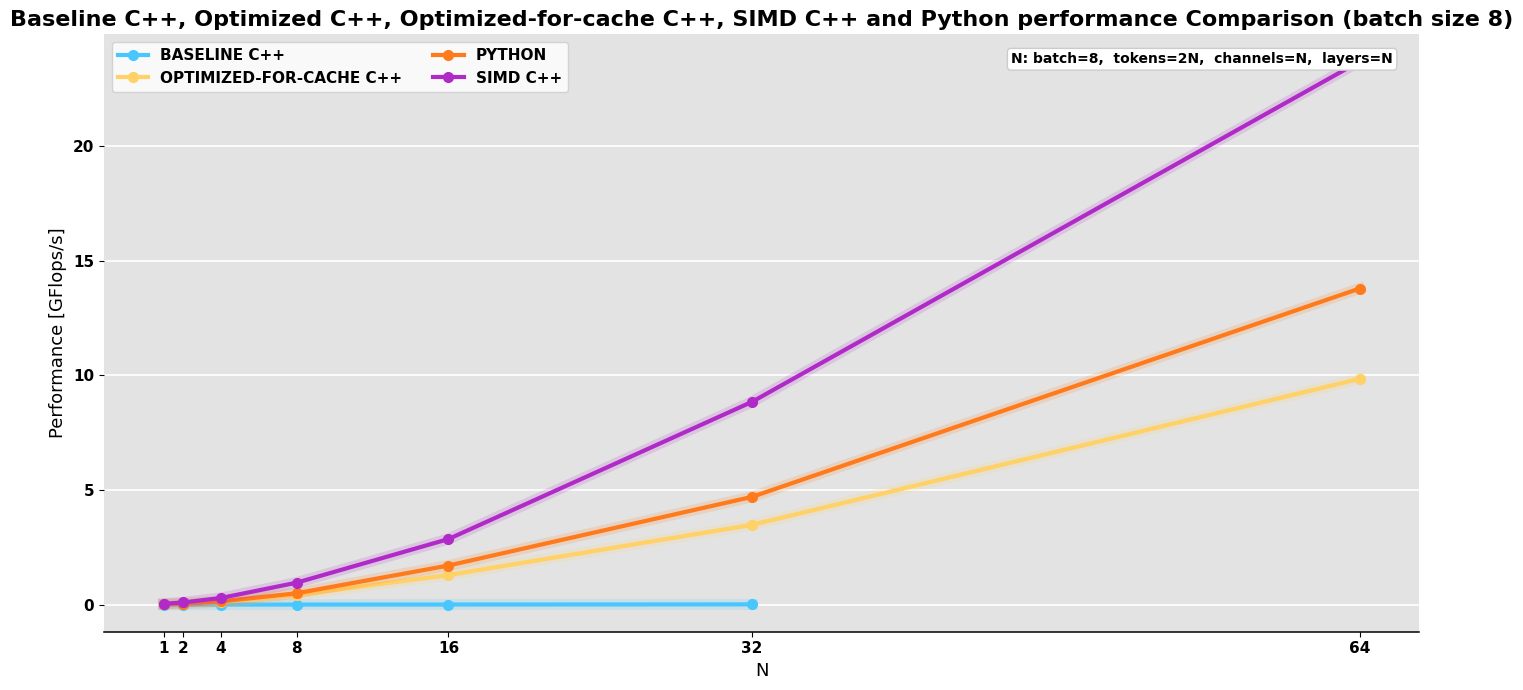

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/end_to_end/end_to_end_with_baseline_log.png


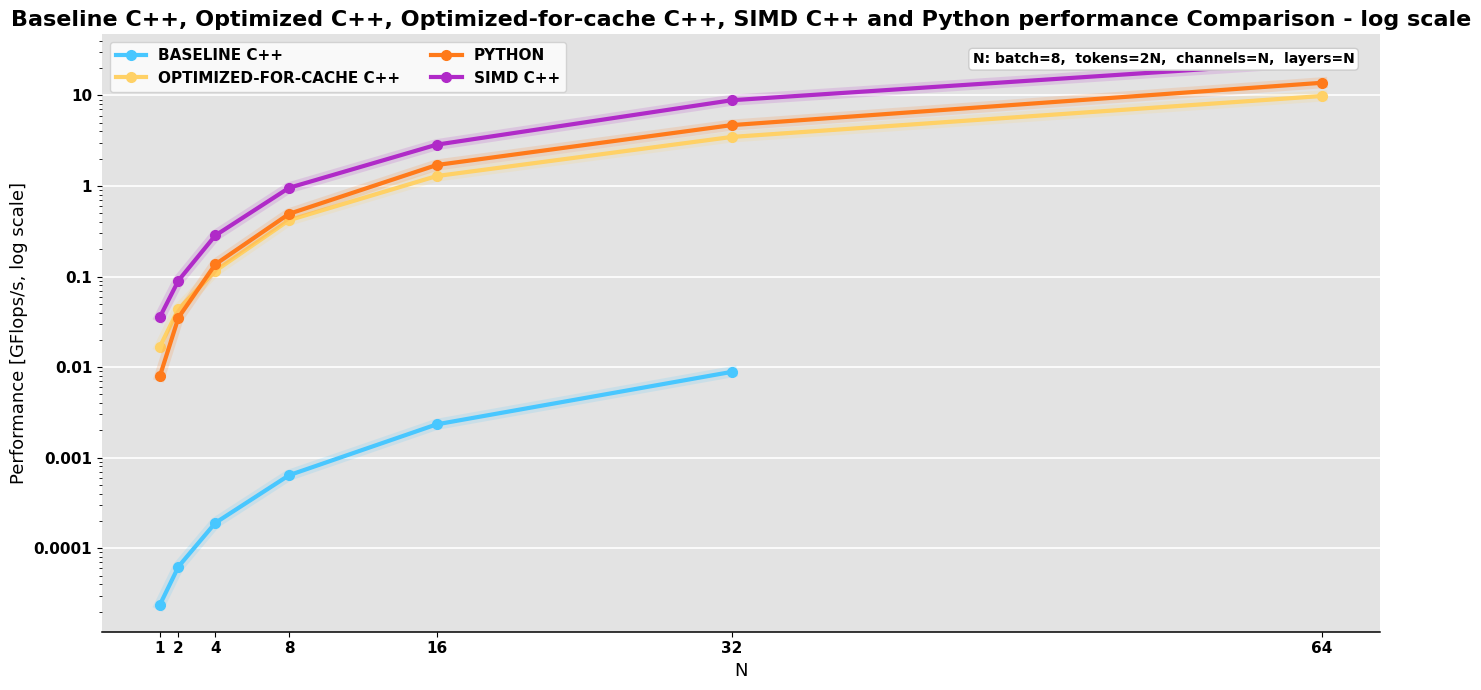

In [160]:
def plot_end_to_end_runtime(machine=MACHINE, include_baseline=False):
    df = add_gflops_per_second(end_to_end)
    labels = ["Baseline C++", "Optimized C++", "Optimized-for-cache C++", "Python", "SIMD C++"]
    if not include_baseline:
        labels = [x for x in labels if x != "Baseline C++"]

    fig, ax = plt.subplots(figsize=(14, 7))
    for label in labels:
        part = df[df["label"] == label].sort_values("n")
        if part.empty:
            continue
        color = COLORS.get(label)
        ax.plot(part["n"], part["gflops_per_second"], marker="o", markersize=7, linewidth=3, color=color, label=label.upper())
        ax.plot(part["n"], part["gflops_per_second"], linewidth=8, color=color, alpha=0.16)

    ax.set_title(("Baseline C++, " if include_baseline else "") + "Optimized C++, Optimized-for-cache C++, SIMD C++ and Python performance Comparison (batch size 8)")
    ax.set_xlabel("N")
    ax.set_ylabel("Performance [GFlops/s]")
    ax.yaxis.set_major_formatter(FuncFormatter(perf_formatter))
    ax.set_xticks(sorted(df["n"].unique()))
    ax.set_xticklabels([str(x) for x in sorted(df["n"].unique())])
    ax.text(0.98, 0.97, "N: batch=8,  tokens=2N,  channels=N,  layers=N", transform=ax.transAxes,
            ha="right", va="top", color="#000000", bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.28"))
    setup_axis(ax)
    ax.legend(loc="upper left", ncol=3 if not include_baseline else 2)
    fig.tight_layout()
    name = "end_to_end_with_baseline.png" if include_baseline else "end_to_end_optimized_cache_simd_python.png"
    savefig(fig, name)
    plt.show()



def plot_end_to_end_runtime_log(machine=MACHINE, include_baseline=True):
    df = add_gflops_per_second(end_to_end)
    labels = ["Baseline C++", "Optimized C++", "Optimized-for-cache C++", "Python", "SIMD C++"]
    if not include_baseline:
        labels = [x for x in labels if x != "Baseline C++"]

    available = [label for label in labels if label in set(df["label"])]
    if include_baseline and "Baseline C++" not in available:
        print("Skipping baseline log plot: no Baseline C++ end-to-end CSV is loaded for this machine")
        return

    fig, ax = plt.subplots(figsize=(14, 7))
    for label in available:
        part = df[df["label"] == label].sort_values("n")
        color = COLORS.get(label)
        ax.plot(part["n"], part["gflops_per_second"], marker="o", markersize=7, linewidth=3, color=color, label=label.upper())
        ax.plot(part["n"], part["gflops_per_second"], linewidth=8, color=color, alpha=0.16)

    ax.set_title("Baseline C++, Optimized C++, Optimized-for-cache C++, SIMD C++ and Python performance Comparison - log scale")
    ax.set_xlabel("N")
    ax.set_ylabel("Performance [GFlops/s, log scale]")
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(perf_formatter))
    ax.set_xticks(sorted(df["n"].unique()))
    ax.set_xticklabels([str(x) for x in sorted(df["n"].unique())])
    ax.text(0.98, 0.97, "N: batch=8,  tokens=2N,  channels=N,  layers=N", transform=ax.transAxes,
            ha="right", va="top", color="#000000", bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.28"))
    setup_axis(ax)
    ax.legend(loc="upper left", ncol=2)
    fig.tight_layout()
    savefig(fig, "end_to_end_with_baseline_log.png")
    plt.show()

plot_end_to_end_runtime(include_baseline=False)
if "Baseline C++" in set(end_to_end["label"]):
    plot_end_to_end_runtime(include_baseline=True)
plot_end_to_end_runtime_log(include_baseline=True)


## Baseline end-to-end vs other implementations

This reproduces the baseline-vs-optimized-vs-SIMD-vs-Python style plot and also creates a log-scale version. M1 is the default here because it now has baseline end-to-end data.


Skipping missing end_to_end CSV for Optimized C++: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/CSVs/Old/2026-05-30/optimized_c_timing_results_2026-05-30_16-52-09.csv
Baseline end-to-end data: M1
Output: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/end_to_end_baseline


,count,min,max
label,,,
Baseline C++,6,988.479838,1.006918e+06
Optimized-for-cache C++,7,1.397828,1.411384e+04
Python,7,2.939018,1.008019e+04
SIMD C++,7,0.656672,5.865452e+03


Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/end_to_end_baseline/end_to_end_baseline_vs_others.png


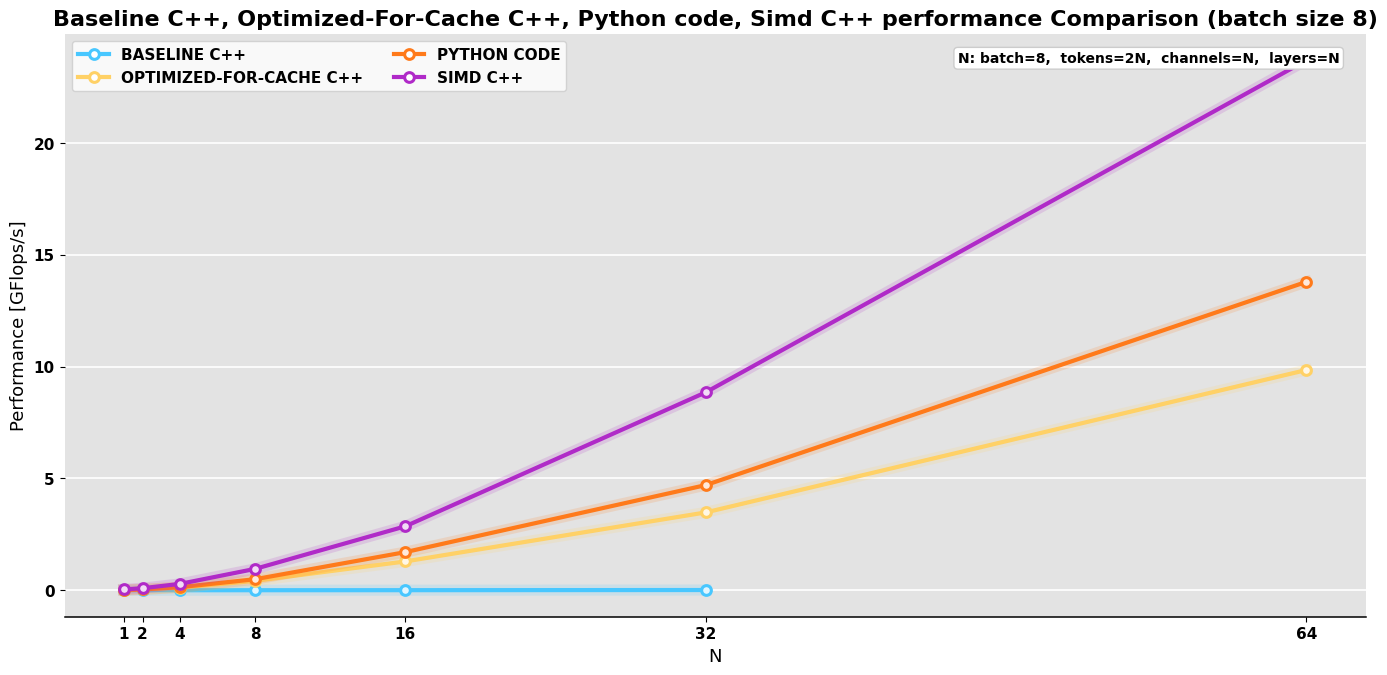

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/end_to_end_baseline/end_to_end_baseline_vs_others_log.png


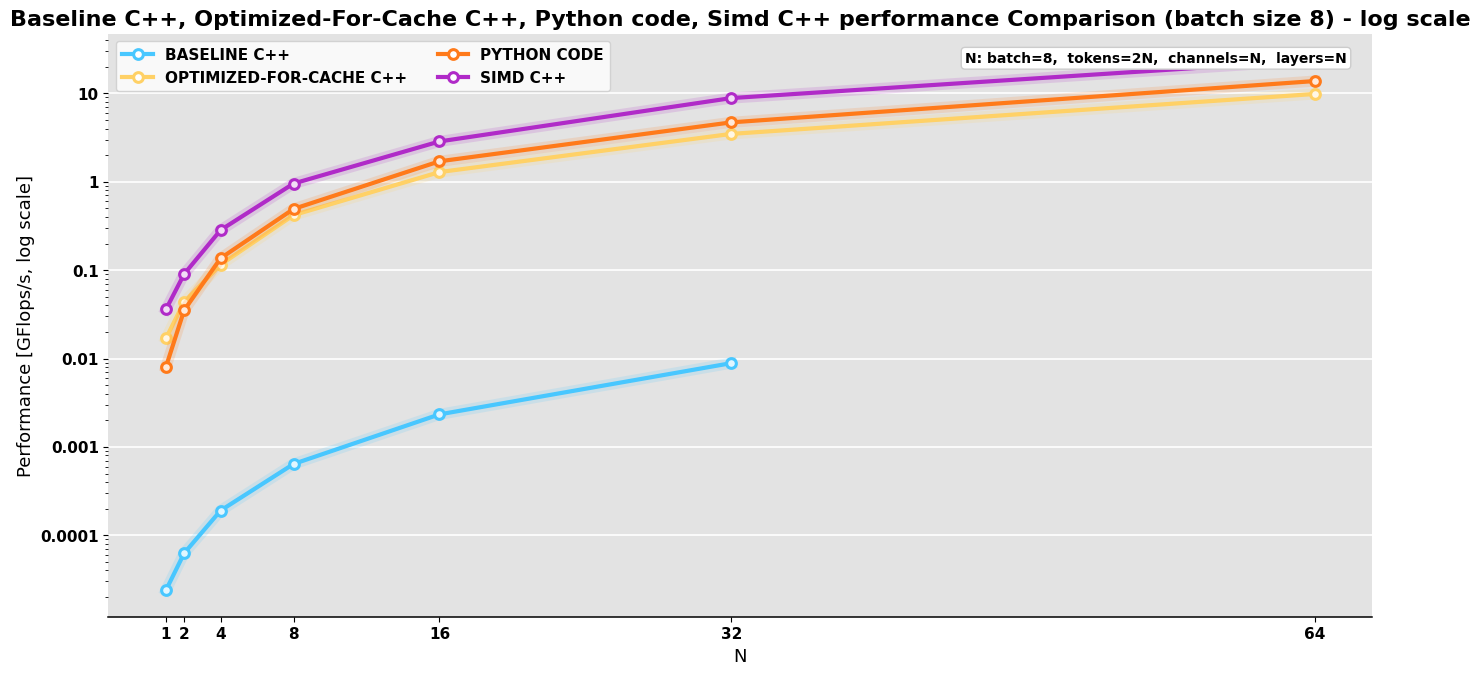

In [161]:
END_TO_END_BASELINE_MACHINE = "M1"

baseline_end_to_end = load_group(END_TO_END_BASELINE_MACHINE, "end_to_end")
BASELINE_E2E_PLOT_DIR = BASE / "Results" / "timing_results" / "Plots" / "comparison_plots" / END_TO_END_BASELINE_MACHINE / "end_to_end_baseline"
BASELINE_E2E_PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Baseline end-to-end data: {END_TO_END_BASELINE_MACHINE}")
print(f"Output: {BASELINE_E2E_PLOT_DIR}")
display(baseline_end_to_end.groupby("label")["avg_ms"].agg(["count", "min", "max"]))

def save_baseline_e2e_fig(fig, name):
    out = BASELINE_E2E_PLOT_DIR / name
    fig.savefig(out, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out}")
    return out

def plot_baseline_end_to_end_comparison(log_scale=False):
    df = add_gflops_per_second(baseline_end_to_end)
    if df.empty:
        print("No end-to-end data loaded for baseline comparison")
        return

    labels = [
        "Baseline C++",
        "Optimized C++",
        "Optimized-for-cache C++",
        "Python",
        "SIMD C++",
    ]
    available = [label for label in labels if label in set(df["label"])]
    if "Baseline C++" not in available:
        print("No Baseline C++ end-to-end data loaded; skipping baseline comparison")
        return

    display_names = {
        "Baseline C++": "BASELINE C++",
        "Optimized C++": "OPTIMIZED C++",
        "Optimized-for-cache C++": "OPTIMIZED-FOR-CACHE C++",
        "Python": "PYTHON CODE",
        "SIMD C++": "SIMD C++",
    }

    fig, ax = plt.subplots(figsize=(14, 7))
    for label in available:
        part = df[df["label"] == label].sort_values("n")
        color = COLORS.get(label, "#d6d8e0")
        ax.plot(
            part["n"],
            part["gflops_per_second"],
            marker="o",
            markersize=7,
            linewidth=3,
            color=color,
            markerfacecolor="white",
            markeredgewidth=2.2,
            label=display_names[label],
        )
        ax.plot(part["n"], part["gflops_per_second"], linewidth=8, color=color, alpha=0.16)

    title_parts = [display_names[label].title().replace("Code", "code") for label in available]
    scale_suffix = " - log scale" if log_scale else ""
    ax.set_title(f"{', '.join(title_parts)} performance Comparison (batch size 8){scale_suffix}")
    ax.set_xlabel("N")
    ax.set_ylabel("Performance [GFlops/s]" if not log_scale else "Performance [GFlops/s, log scale]")
    if log_scale:
        ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(perf_formatter))
    ax.set_xticks(sorted(df["n"].unique()))
    ax.set_xticklabels([str(x) for x in sorted(df["n"].unique())])
    ax.text(
        0.98,
        0.97,
        "N: batch=8,  tokens=2N,  channels=N,  layers=N",
        transform=ax.transAxes,
        ha="right",
        va="top",
        color="#000000",
        bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.28"),
    )
    setup_axis(ax)
    ax.legend(loc="upper left", ncol=2)
    fig.tight_layout(pad=1.6)
    filename = "end_to_end_baseline_vs_others_log.png" if log_scale else "end_to_end_baseline_vs_others.png"
    save_baseline_e2e_fig(fig, filename)
    plt.show()

plot_baseline_end_to_end_comparison(log_scale=False)
plot_baseline_end_to_end_comparison(log_scale=True)


## Per-kernel and end-to-end analysis


Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/speedups/python_vs_simd_cpp_per_kernel_speedup.png


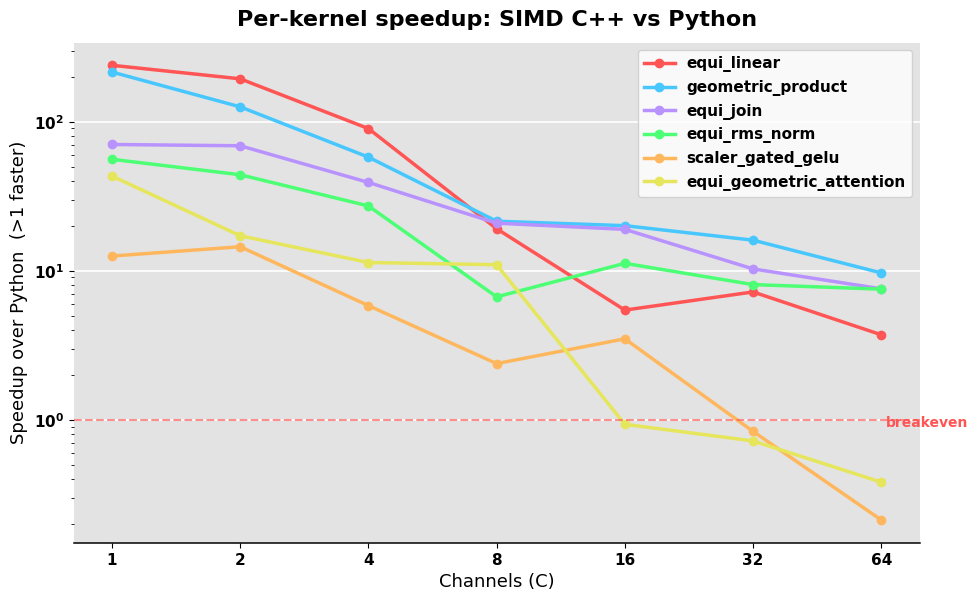

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/speedups/python_vs_simd_cpp_end_to_end_speedup_ratio_log.png


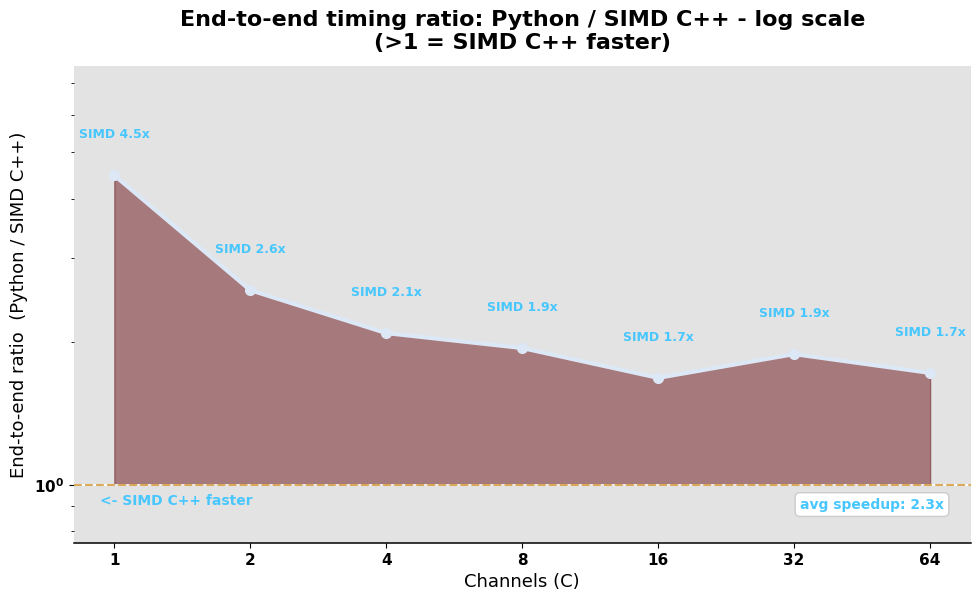

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/speedups/optimized_for_cache_cpp_vs_python_per_kernel_speedup.png


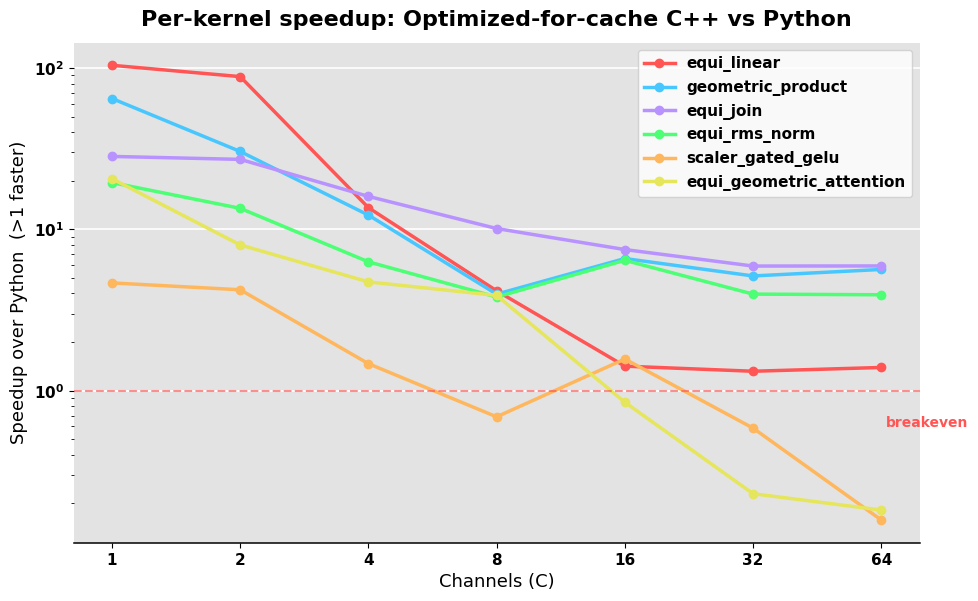

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/speedups/optimized_for_cache_cpp_vs_python_end_to_end.png


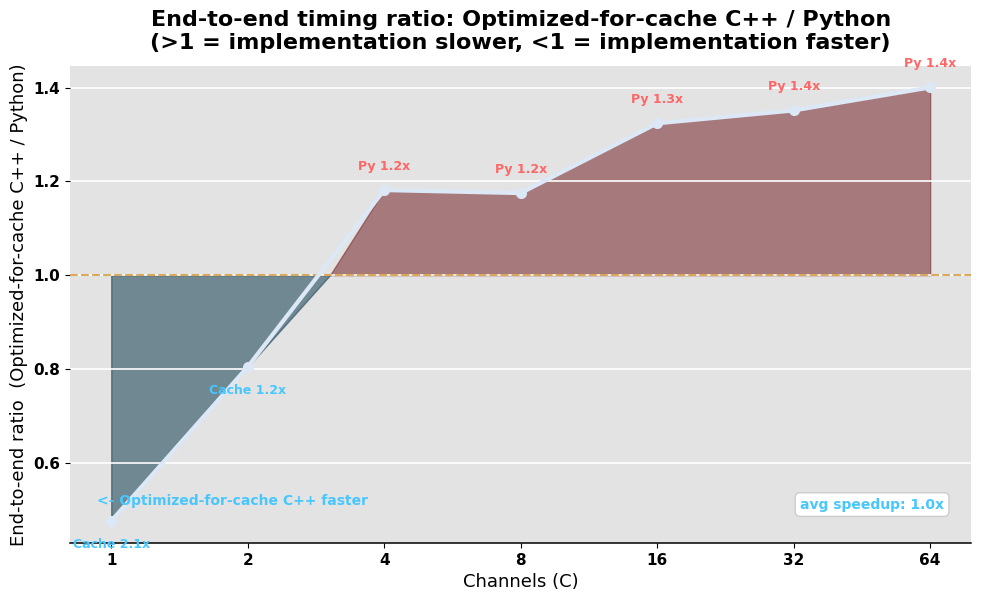

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/speedups/baseline_cpp_vs_simd_cpp_per_kernel_speedup.png


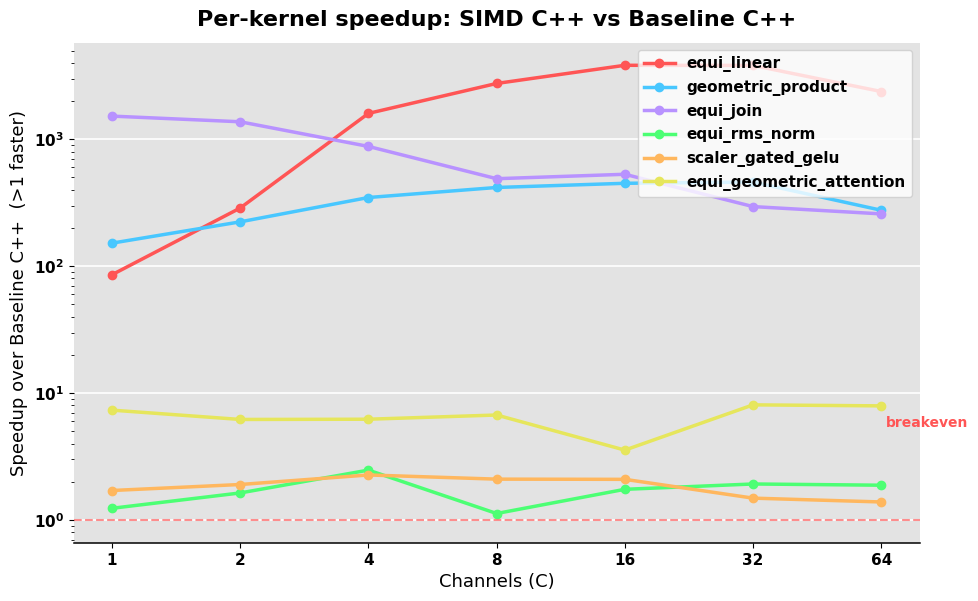

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/speedups/baseline_cpp_vs_simd_cpp_end_to_end_speedup_ratio_log.png


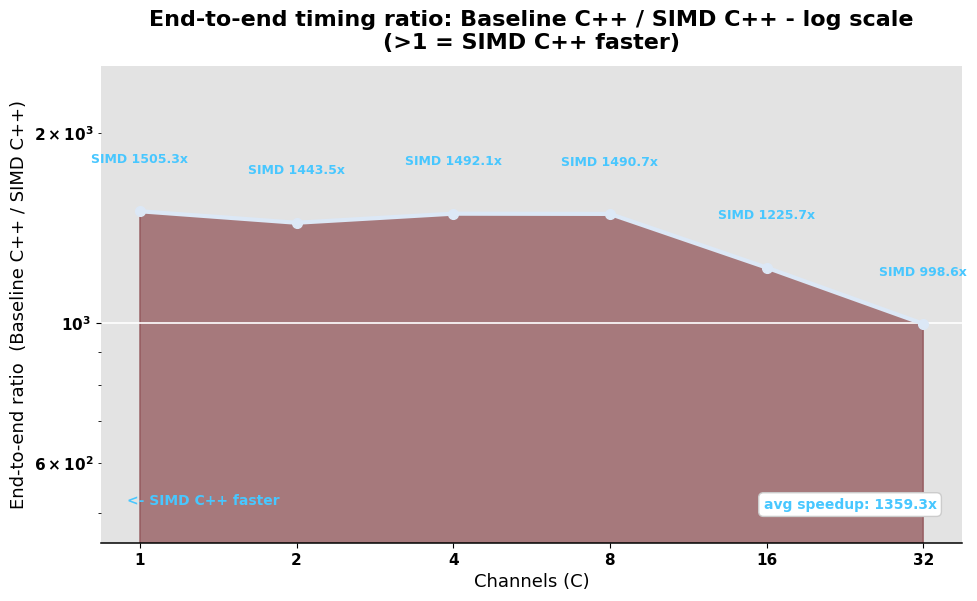

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/speedups/baseline_cpp_vs_optimized_for_cache_cpp_per_kernel_speedup.png


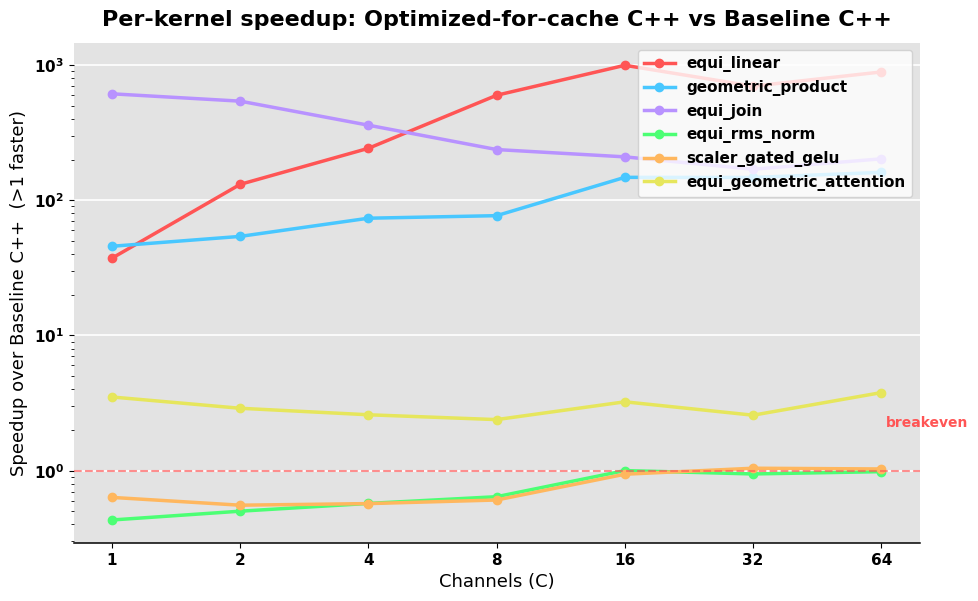

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/speedups/baseline_cpp_vs_optimized_for_cache_cpp_end_to_end_speedup_ratio_log.png


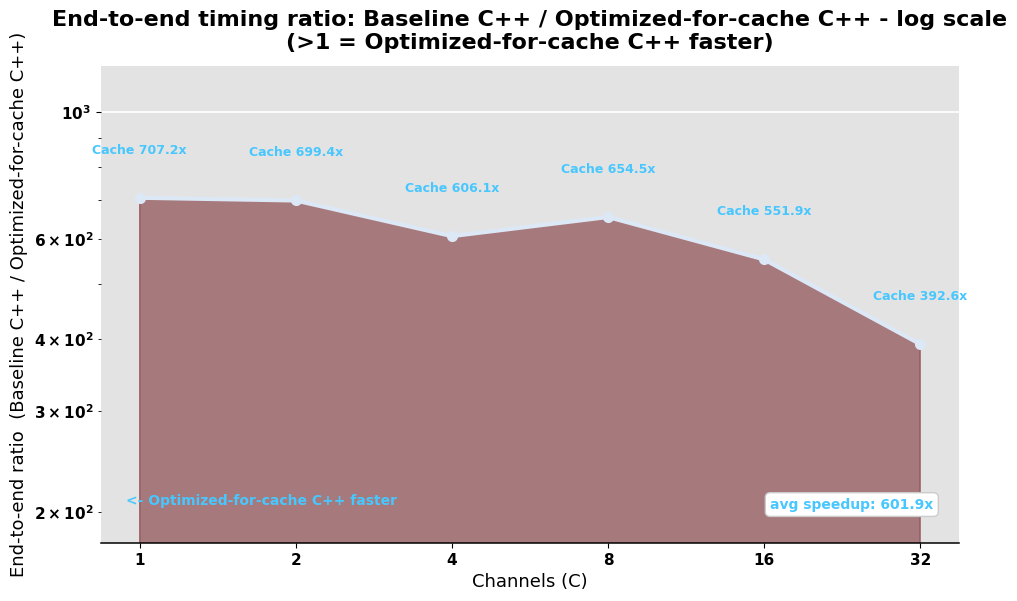

In [162]:
def short_label(label):
    if label == "Python":
        return "Py"
    if label == "Baseline C++":
        return "Base"
    if label == "SIMD C++":
        return "SIMD"
    if label == "Optimized-for-cache C++":
        return "Cache"
    return label.split()[0]


def safe_label(label):
    return label.lower().replace(" ", "_").replace("+", "p").replace("-", "_")


def plot_kernel_and_e2e_analysis(impl_label, reference_label="Python", machine=MACHINE, e2e_speedup=False):
    per_kernel_labels = set(per_kernel["label"])
    end_to_end_labels = set(end_to_end["label"])
    if impl_label not in per_kernel_labels:
        print(f"Skipping {impl_label}: no per-kernel data")
        return
    if impl_label not in end_to_end_labels:
        print(f"Skipping {impl_label}: no end-to-end data")
        return
    if reference_label not in per_kernel_labels or reference_label not in end_to_end_labels:
        print(f"Need {reference_label} per-kernel and end-to-end data for ratio plots")
        return

    labels = [reference_label, impl_label]
    pk = per_kernel[per_kernel["label"].isin(labels)]
    pk_pivot = (
        pk.pivot_table(index=["kernel", "n"], columns="label", values="avg_ms", aggfunc="mean")
        .reset_index()
        .dropna(subset=labels)
    )
    if pk_pivot.empty:
        print(f"No overlapping per-kernel data for {impl_label} vs {reference_label}")
        return
    pk_pivot["speedup"] = pk_pivot[reference_label] / pk_pivot[impl_label]

    e2e = pivot_runtime(end_to_end[end_to_end["label"].isin(labels)]).dropna(subset=labels)
    if e2e.empty:
        print(f"No overlapping end-to-end data for {impl_label} vs {reference_label}")
        return
    e2e["speedup"] = e2e[reference_label] / e2e[impl_label]
    if e2e_speedup:
        e2e["ratio"] = e2e["speedup"]
        e2e_ratio_label = f"{reference_label} / {impl_label}"
        e2e_title_help = f">1 = {impl_label} faster"
        faster_label = f"{impl_label} faster"
    else:
        e2e["ratio"] = e2e[impl_label] / e2e[reference_label]
        e2e_ratio_label = f"{impl_label} / {reference_label}"
        e2e_title_help = ">1 = implementation slower, <1 = implementation faster"
        faster_label = f"{impl_label} faster"

    analysis_kernels = [
        "equi_linear",
        "geometric_product",
        "equi_join",
        "equi_rms_norm",
        "scaler_gated_gelu",
        "equi_geometric_attention",
    ]

    fig1, ax1 = plt.subplots(figsize=(10, 6.2))
    for kernel in analysis_kernels:
        part = pk_pivot[pk_pivot["kernel"] == kernel].sort_values("n")
        if part.empty:
            continue
        ax1.plot(part["n"], part["speedup"], marker="o", markersize=6, linewidth=2.5,
                 color=KERNEL_COLORS.get(kernel), label=kernel)
    ax1.axhline(1.0, color="#ff5555", linestyle="--", alpha=0.65)
    ax1.text(0.96, 0.24, "breakeven", transform=ax1.transAxes, color="#ff5555", ha="left", va="center", fontsize=10)
    ax1.set_title(f"Per-kernel speedup: {impl_label} vs {reference_label}", pad=12)
    ax1.set_xlabel("Channels (C)")
    ax1.set_ylabel(f"Speedup over {reference_label}  (>1 faster)")
    ax1.set_xscale("log", base=2)
    ax1.set_yscale("log")
    ax1.set_xticks(sorted(pk_pivot["n"].unique()))
    ax1.set_xticklabels([str(x) for x in sorted(pk_pivot["n"].unique())])
    ax1.yaxis.set_major_locator(LogLocator(base=10))
    setup_axis(ax1)
    ax1.legend(loc="upper right")
    fig1.tight_layout(pad=1.4)
    if e2e_speedup:
        kernel_filename = f"{safe_label(reference_label)}_vs_{safe_label(impl_label)}_per_kernel_speedup.png"
    else:
        kernel_filename = f"{safe_label(impl_label)}_vs_{safe_label(reference_label)}_per_kernel_speedup.png"
    savefig(fig1, kernel_filename)
    plt.show()

    xs = e2e["n"]
    ys = e2e["ratio"]
    ratio_min = float(ys.min())
    ratio_max = float(ys.max())
    ratio_axis_log = e2e_speedup or reference_label == "Baseline C++" or ratio_min < 0.1 or (ratio_max / ratio_min) > 20

    fig2, ax2 = plt.subplots(figsize=(10, 6.2))
    ax2.axhline(1.0, color="#d8a14a", linestyle="--", alpha=0.9)
    ax2.fill_between(xs, ys, 1, where=ys < 1, color="#1d4658", alpha=0.58, interpolate=True)
    ax2.fill_between(xs, ys, 1, where=ys > 1, color="#7a2d32", alpha=0.58, interpolate=True)
    ax2.plot(xs, ys, marker="o", markersize=7, linewidth=3, color="#dce8f6")

    ratio_span = max(ratio_max - ratio_min, 0.08)
    for _, row in e2e.iterrows():
        if e2e_speedup:
            text = f"{short_label(impl_label)} {row['ratio']:.1f}x"
            color = "#48c7ff" if row["ratio"] >= 1 else "#ff6666"
            y = row["ratio"] * 1.18 if ratio_axis_log else row["ratio"] + 0.04 * ratio_span
            va = "bottom"
        elif row["ratio"] < 1:
            text = f"{short_label(impl_label)} {1 / row['ratio']:.1f}x"
            color = "#48c7ff"
            y = row["ratio"] * 0.72 if ratio_axis_log else max(row["ratio"] - 0.04 * ratio_span, row["ratio"] * 0.7)
            va = "top"
        else:
            text = f"{short_label(reference_label)} {row['ratio']:.1f}x"
            color = "#ff6666"
            y = row["ratio"] * 1.25 if ratio_axis_log else row["ratio"] + 0.04 * ratio_span
            va = "bottom"
        ax2.text(row["n"], y, text, color=color, fontsize=9, ha="center", va=va)

    if ratio_axis_log:
        ax2.set_yscale("log")
        ax2.set_ylim(max(ratio_min * 0.45, 1e-6), max(ratio_max * 1.7, 1.5))
        ratio_scale_note = " - log scale"
    else:
        ratio_scale_note = ""

    mean_speedup = float(e2e["speedup"].mean())
    ax2.text(0.03, 0.08, f"<- {faster_label}", transform=ax2.transAxes, color="#48c7ff", fontsize=10)
    ax2.text(0.97, 0.08, f"avg speedup: {mean_speedup:.1f}x", transform=ax2.transAxes,
             ha="right", va="center", color="#48c7ff",
             bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.35"))
    ax2.set_title(f"End-to-end timing ratio: {e2e_ratio_label}{ratio_scale_note}\n({e2e_title_help})", pad=12)
    ax2.set_xlabel("Channels (C)")
    ax2.set_ylabel(f"End-to-end ratio  ({e2e_ratio_label})")
    ax2.set_xscale("log", base=2)
    ax2.set_xticks(sorted(e2e["n"].unique()))
    ax2.set_xticklabels([str(x) for x in sorted(e2e["n"].unique())])
    setup_axis(ax2)
    fig2.tight_layout(pad=1.4)
    name_suffix = "_ratio_log" if ratio_axis_log else ""
    if e2e_speedup:
        e2e_filename = f"{safe_label(reference_label)}_vs_{safe_label(impl_label)}_end_to_end_speedup{name_suffix}.png"
    else:
        e2e_filename = f"{safe_label(impl_label)}_vs_{safe_label(reference_label)}_end_to_end{name_suffix}.png"
    savefig(fig2, e2e_filename)
    plt.show()

plot_kernel_and_e2e_analysis("SIMD C++", reference_label="Python", e2e_speedup=True)
plot_kernel_and_e2e_analysis("Optimized-for-cache C++", reference_label="Python")
plot_kernel_and_e2e_analysis("SIMD C++", reference_label="Baseline C++", e2e_speedup=True)
plot_kernel_and_e2e_analysis("Optimized-for-cache C++", reference_label="Baseline C++", e2e_speedup=True)


## Per-kernel performance curves

Plot one kernel at a time as GFlops/s, with all available implementations for the selected machine.


Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/per_kernel/kernel_performance_equi_geometric_attention.png


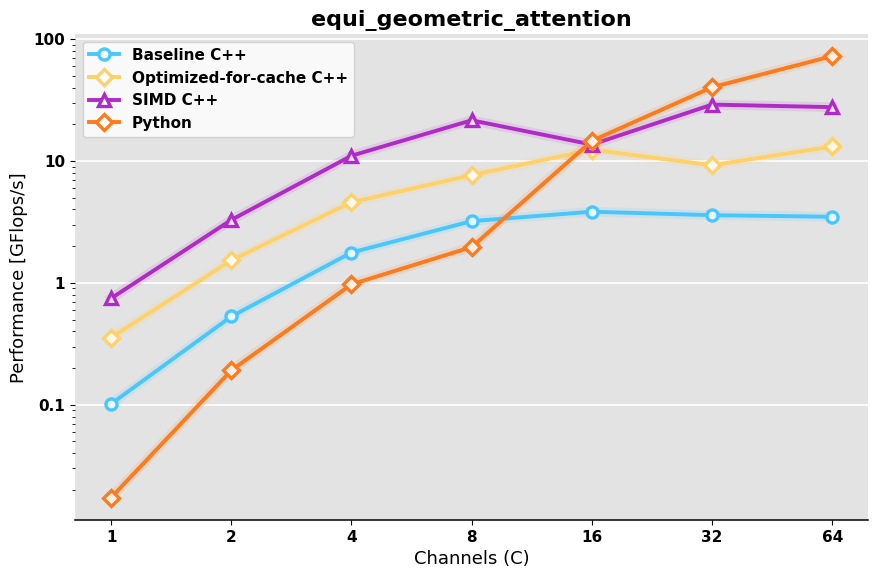

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/per_kernel/kernel_performance_equi_join.png


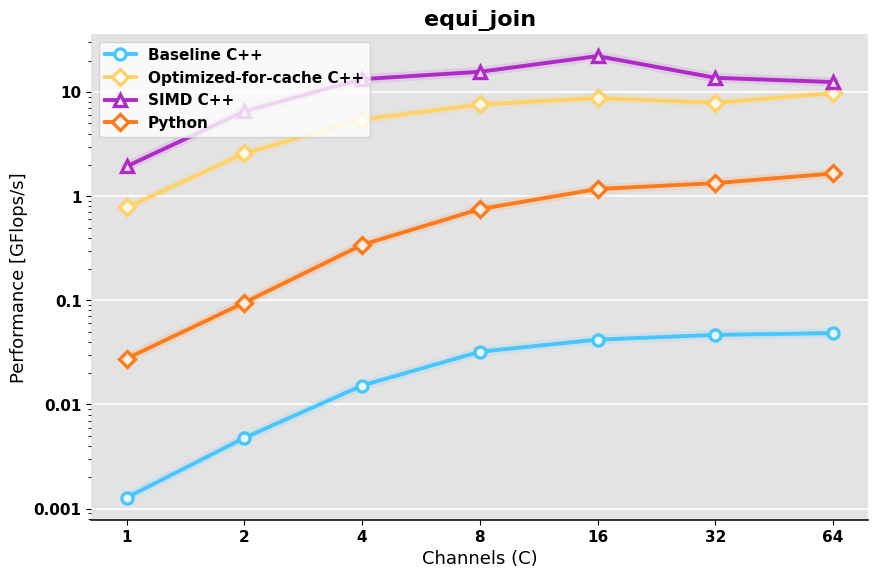

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/per_kernel/kernel_performance_equi_linear.png


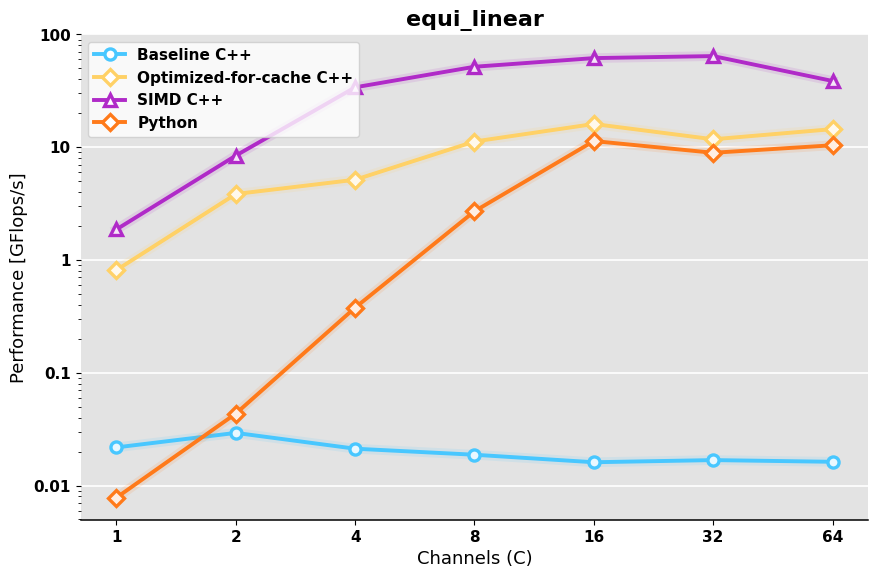

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/per_kernel/kernel_performance_equi_rms_norm.png


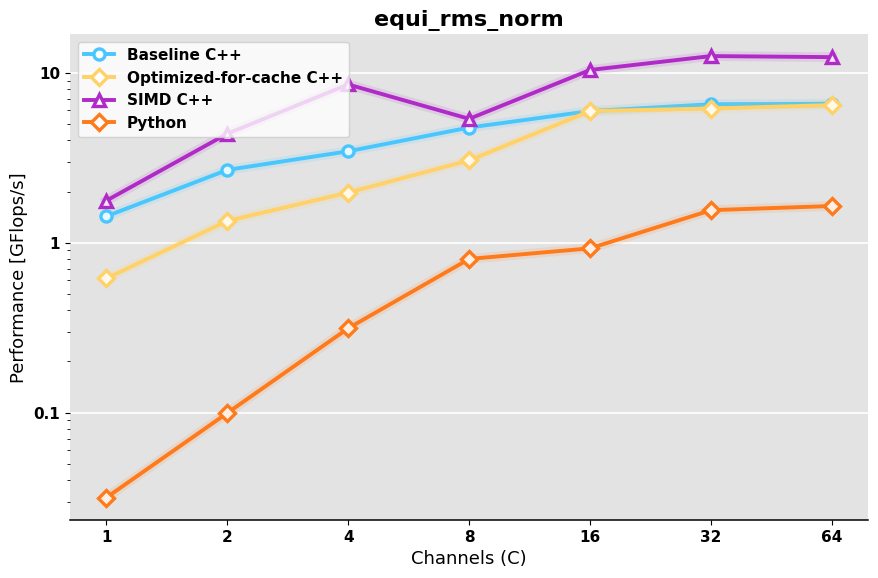

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/per_kernel/kernel_performance_geometric_product.png


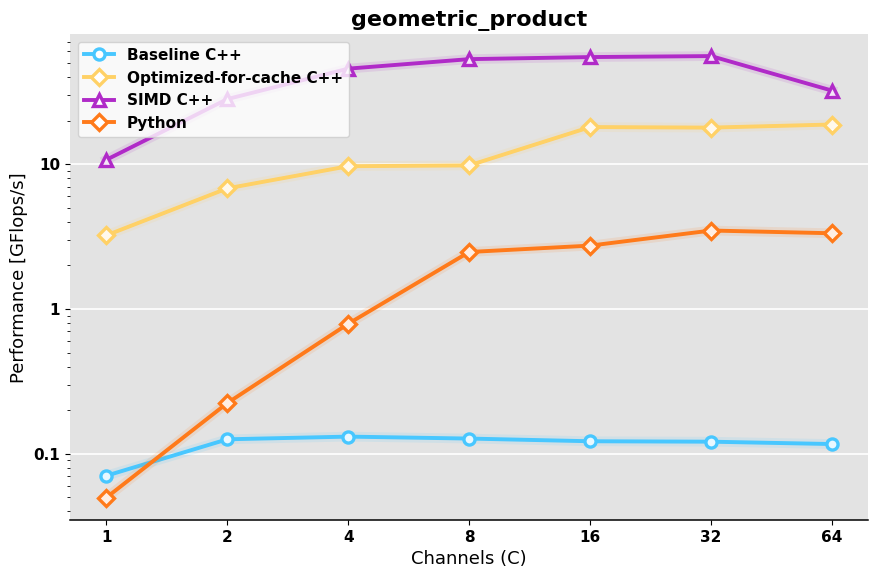

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/per_kernel/kernel_performance_scaler_gated_gelu.png


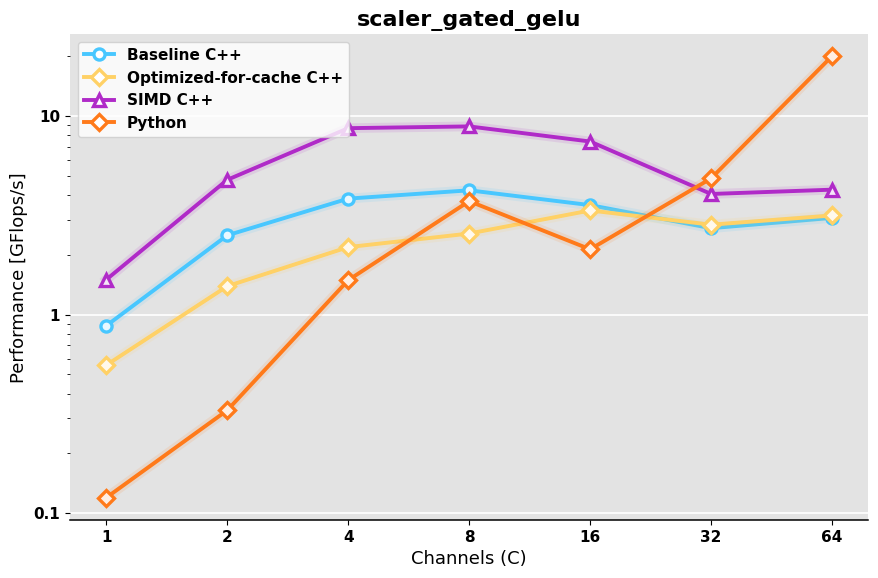

In [163]:
def plot_kernel_runtime(kernel="geometric_product", machine=MACHINE):
    df = add_kernel_gflops_per_second(per_kernel[per_kernel["kernel"] == kernel])
    if df.empty:
        print(f"No per-kernel data for {kernel}")
        return

    label_order = ["Baseline C++", "Optimized C++", "Optimized-for-cache C++", "SIMD C++", "Python"]
    marker_map = {
        "Baseline C++": "o",
        "Optimized C++": "s",
        "Optimized-for-cache C++": "D",
        "SIMD C++": "^",
        "Python": "D",
    }

    fig, ax = plt.subplots(figsize=(9, 6))
    for label in label_order:
        part = df[df["label"] == label].sort_values("n")
        if part.empty:
            continue
        color = COLORS.get(label, "#d6d8e0")
        ax.plot(
            part["n"],
            part["gflops_per_second"],
            marker=marker_map.get(label, "o"),
            markersize=8,
            linewidth=2.8,
            color=color,
            markerfacecolor="white",
            markeredgewidth=2.4,
            label=label,
        )
        ax.plot(part["n"], part["gflops_per_second"], linewidth=7, color=color, alpha=0.12)

    ax.set_title(kernel)
    ax.set_xlabel("Channels (C)")
    ax.set_ylabel("Performance [GFlops/s]")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(sorted(df["n"].unique()))
    ax.set_xticklabels([str(x) for x in sorted(df["n"].unique())])
    ax.yaxis.set_major_formatter(FuncFormatter(perf_formatter))
    setup_axis(ax)
    ax.legend(loc="upper left")
    fig.tight_layout(pad=1.5)
    savefig(fig, f"kernel_performance_{kernel}.png")
    plt.show()

for kernel in sorted(per_kernel["kernel"].unique()):
    plot_kernel_runtime(kernel)


## Top SIMD speedup kernels

For M2 this plots `Baseline C++` vs `SIMD C++`. For M1, where no baseline per-kernel CSV is present, it falls back to `Python` vs `SIMD C++`.


Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/speedups/top_2_speedup_baseline_cpp_vs_simd_cpp.png


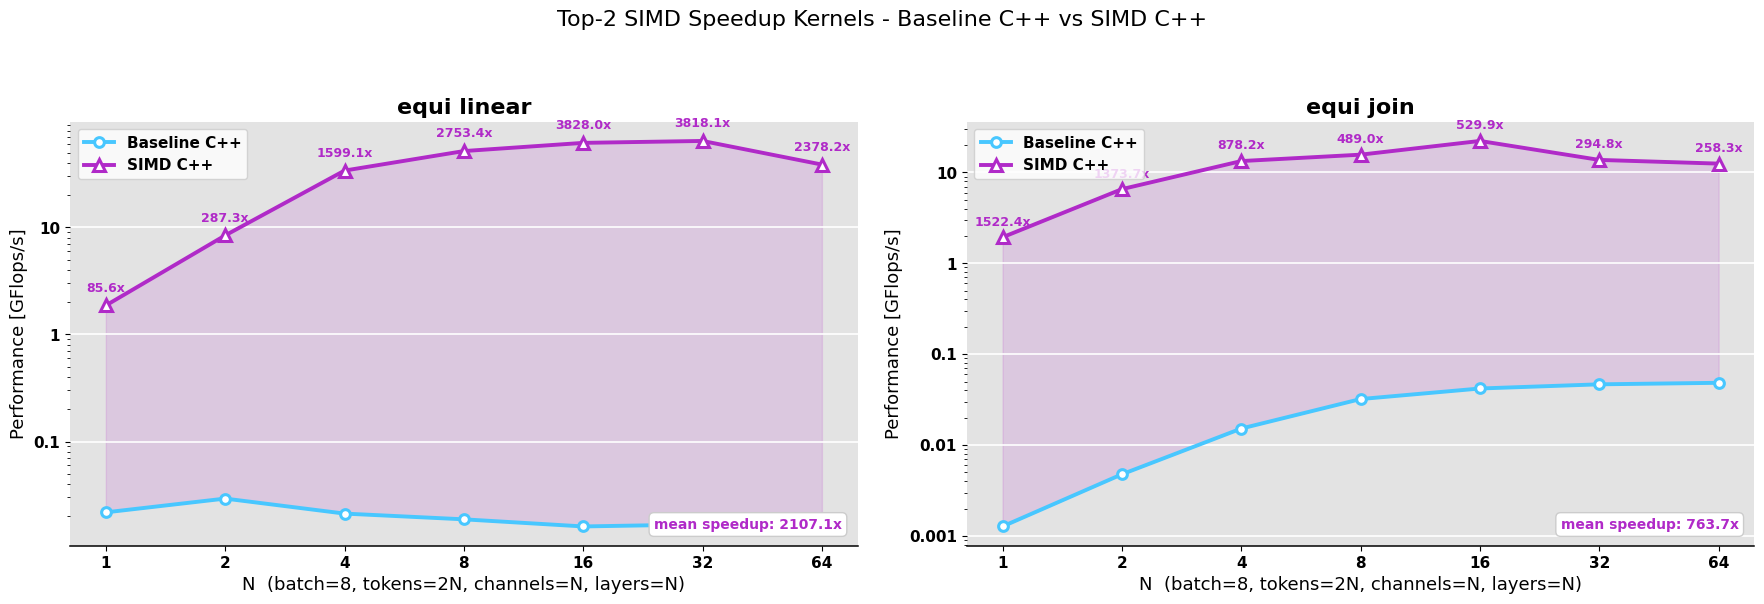

In [164]:
def choose_speedup_baseline():
    labels = set(per_kernel["label"])
    if "Baseline C++" in labels:
        return "Baseline C++"
    if "Python" in labels:
        return "Python"
    raise ValueError("Need either Baseline C++ or Python per-kernel data for speedup plots")

def plot_top_speedup_kernels(compare_label="SIMD C++", baseline_label=None, top_n=2):
    baseline_label = baseline_label or choose_speedup_baseline()
    labels = set(per_kernel["label"])
    if baseline_label not in labels or compare_label not in labels:
        print(f"Skipping top speedup plot: need {baseline_label} and {compare_label}")
        return

    timing_pivot = (
        per_kernel[per_kernel["label"].isin([baseline_label, compare_label])]
        .pivot_table(index=["kernel", "n"], columns="label", values="avg_ms", aggfunc="mean")
        .reset_index()
        .dropna(subset=[baseline_label, compare_label])
    )
    timing_pivot["speedup"] = timing_pivot[baseline_label] / timing_pivot[compare_label]
    perf_pivot = (
        add_kernel_gflops_per_second(per_kernel[per_kernel["label"].isin([baseline_label, compare_label])])
        .pivot_table(index=["kernel", "n"], columns="label", values="gflops_per_second", aggfunc="mean")
        .reset_index()
        .dropna(subset=[baseline_label, compare_label])
    )
    pivot = perf_pivot.merge(timing_pivot[["kernel", "n", "speedup"]], on=["kernel", "n"], how="inner")
    top_kernels = (
        pivot.groupby("kernel")["speedup"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )
    if not top_kernels:
        print("No overlapping kernels for speedup plot")
        return

    fig, axes = plt.subplots(1, len(top_kernels), figsize=(9 * len(top_kernels), 6), squeeze=False)
    fig.suptitle(f"Top-{len(top_kernels)} SIMD Speedup Kernels - {baseline_label} vs {compare_label}", fontsize=16, y=1.02)

    for ax, kernel in zip(axes[0], top_kernels):
        part = pivot[pivot["kernel"] == kernel].sort_values("n")
        base_color = COLORS.get(baseline_label, "#48c7ff")
        simd_color = COLORS.get(compare_label, "#b892ff")

        ax.plot(part["n"], part[baseline_label], marker="o", markersize=7, linewidth=2.8,
                color=base_color, markerfacecolor="white", markeredgewidth=2.2, label=baseline_label)
        ax.plot(part["n"], part[compare_label], marker="^", markersize=8, linewidth=2.8,
                color=simd_color, markerfacecolor="white", markeredgewidth=2.2, label=compare_label)
        ax.fill_between(part["n"], part[baseline_label], part[compare_label], color=simd_color, alpha=0.14)

        for _, row in part.iterrows():
            ax.text(row["n"], row[compare_label] * 1.35, f"{row['speedup']:.1f}x",
                    color=simd_color, fontsize=9, ha="center")

        mean_speedup = part["speedup"].mean()
        ax.text(0.98, 0.05, f"mean speedup: {mean_speedup:.1f}x", transform=ax.transAxes,
                ha="right", va="center", color=simd_color,
                bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.35"))
        ax.set_title(kernel.replace("_", " "))
        ax.set_xlabel("N  (batch=8, tokens=2N, channels=N, layers=N)")
        ax.set_ylabel("Performance [GFlops/s]")
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(sorted(part["n"].unique()))
        ax.set_xticklabels([str(x) for x in sorted(part["n"].unique())])
        ax.yaxis.set_major_formatter(FuncFormatter(perf_formatter))
        setup_axis(ax)
        ax.legend(loc="upper left")

    fig.tight_layout(pad=2.0)
    safe_base = baseline_label.lower().replace(" ", "_").replace("+", "p")
    safe_cmp = compare_label.lower().replace(" ", "_").replace("+", "p")
    savefig(fig, f"top_{len(top_kernels)}_speedup_{safe_base}_vs_{safe_cmp}.png")
    plt.show()

plot_top_speedup_kernels(compare_label="SIMD C++", top_n=2)


## SIMD vs Baseline C++ per-kernel speedups

These figures are specifically `SIMD C++` vs `Baseline C++`. This section uses `BASELINE_SPEEDUP_MACHINE = "M1"` by default and reads the M1 baseline per-kernel CSV from `Results/timing_results/2026-05-30`.


In [165]:
BASELINE_SPEEDUP_MACHINE = "M1"

baseline_simd_per_kernel = load_group(BASELINE_SPEEDUP_MACHINE, "per_kernel")
required_labels = {"Baseline C++", "SIMD C++"}
missing_labels = required_labels - set(baseline_simd_per_kernel["label"])
if missing_labels:
    raise ValueError(
        f"{BASELINE_SPEEDUP_MACHINE} is missing labels for SIMD-vs-baseline plots: {sorted(missing_labels)}"
    )

BASELINE_PLOT_DIR = BASE / "Results" / "timing_results" / "Plots" / "comparison_plots" / BASELINE_SPEEDUP_MACHINE / "simd_vs_baseline"
BASELINE_PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"SIMD-vs-baseline data: {BASELINE_SPEEDUP_MACHINE}")
print(f"Output: {BASELINE_PLOT_DIR}")

def save_baseline_fig(fig, name):
    out = BASELINE_PLOT_DIR / name
    fig.savefig(out, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out}")
    return out

def baseline_simd_pivot():
    labels = ["Baseline C++", "SIMD C++"]
    timing = (
        baseline_simd_per_kernel[baseline_simd_per_kernel["label"].isin(labels)]
        .pivot_table(index=["kernel", "n"], columns="label", values="avg_ms", aggfunc="mean")
        .reset_index()
        .dropna(subset=labels)
    )
    timing["speedup"] = timing["Baseline C++"] / timing["SIMD C++"]
    performance = (
        add_kernel_gflops_per_second(baseline_simd_per_kernel[baseline_simd_per_kernel["label"].isin(labels)])
        .pivot_table(index=["kernel", "n"], columns="label", values="gflops_per_second", aggfunc="mean")
        .reset_index()
        .dropna(subset=labels)
    )
    return (
        performance.merge(timing[["kernel", "n", "speedup"]], on=["kernel", "n"], how="inner")
        .sort_values(["kernel", "n"])
    )

baseline_vs_simd = baseline_simd_pivot()
display(
    baseline_vs_simd.groupby("kernel")["speedup"]
    .agg(["count", "mean", "min", "max"])
    .sort_values("mean", ascending=False)
)


SIMD-vs-baseline data: M1
Output: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/simd_vs_baseline


,count,mean,min,max
kernel,,,,
equi_linear,7,2107.085187,85.617551,3827.960177
equi_join,7,763.747629,258.262320,1522.441838
geometric_product,7,332.283498,151.885686,460.191654
equi_geometric_attention,7,6.576642,3.553788,8.077174
scaler_gated_gelu,7,1.848104,1.386731,2.263388
equi_rms_norm,7,1.716204,1.124860,2.472521


### Specific function speedups: SIMD vs Baseline

One plot per kernel. Each figure shows baseline and SIMD performance in GFlops/s and annotates the SIMD timing speedup over baseline at each channel count.


Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/simd_vs_baseline/simd_vs_baseline_performance_equi_geometric_attention.png


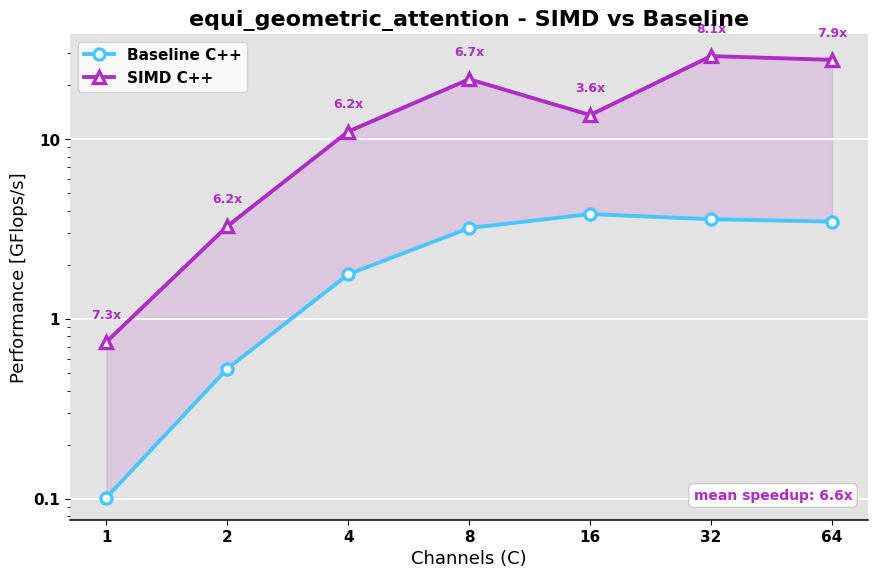

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/simd_vs_baseline/simd_vs_baseline_performance_equi_join.png


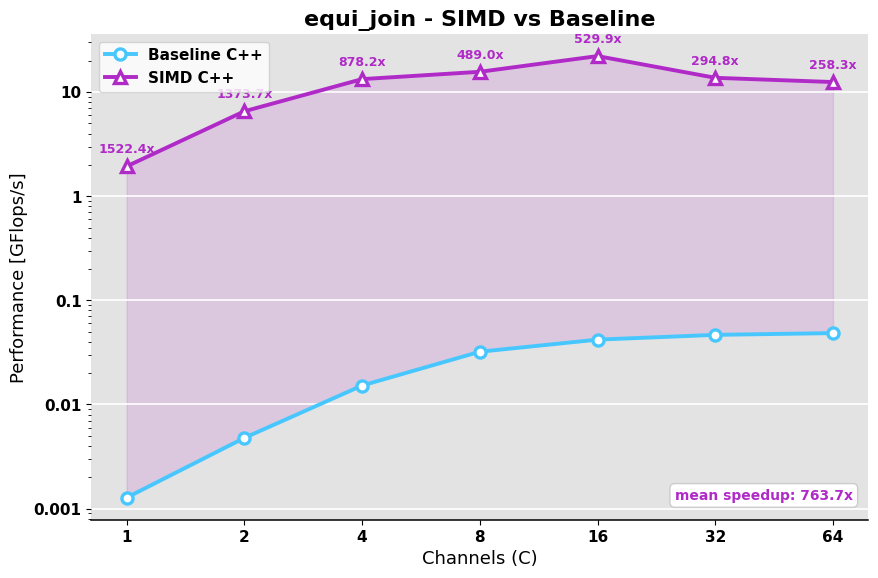

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/simd_vs_baseline/simd_vs_baseline_performance_equi_linear.png


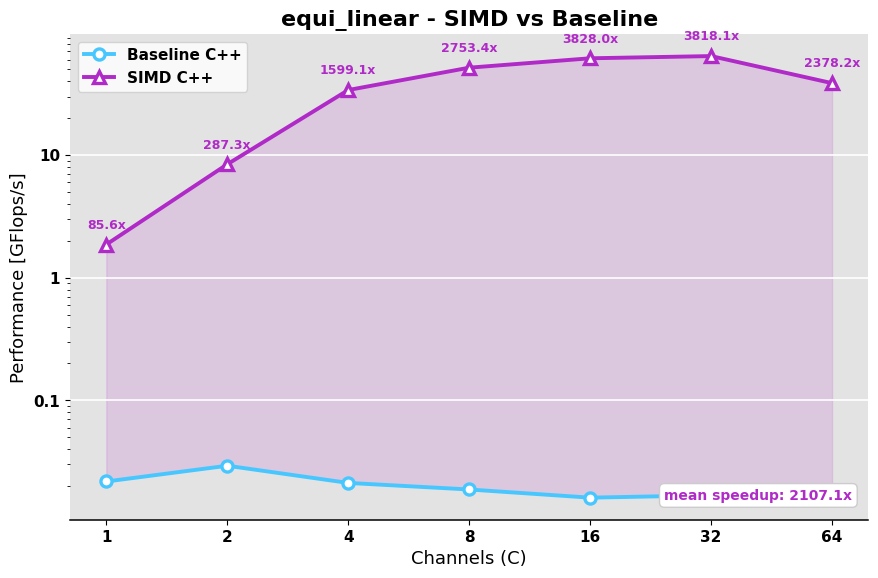

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/simd_vs_baseline/simd_vs_baseline_performance_equi_rms_norm.png


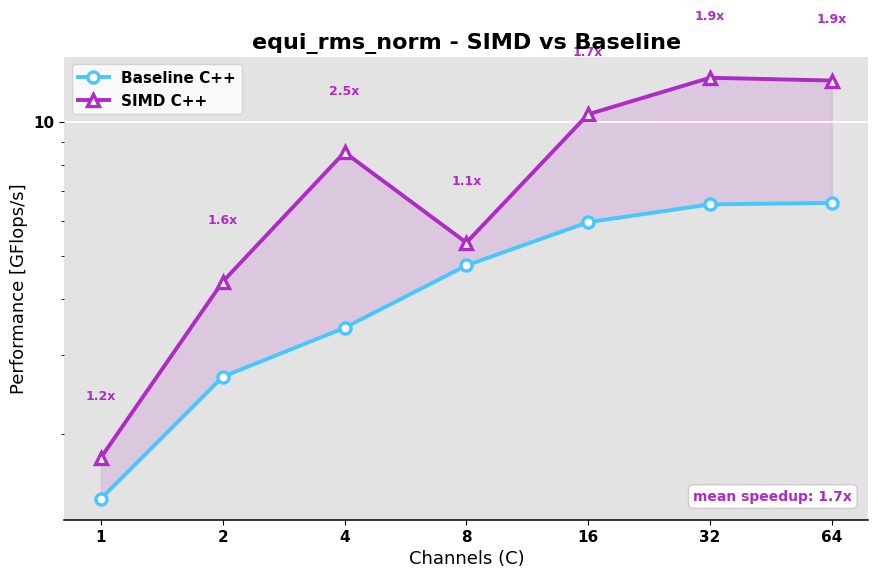

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/simd_vs_baseline/simd_vs_baseline_performance_geometric_product.png


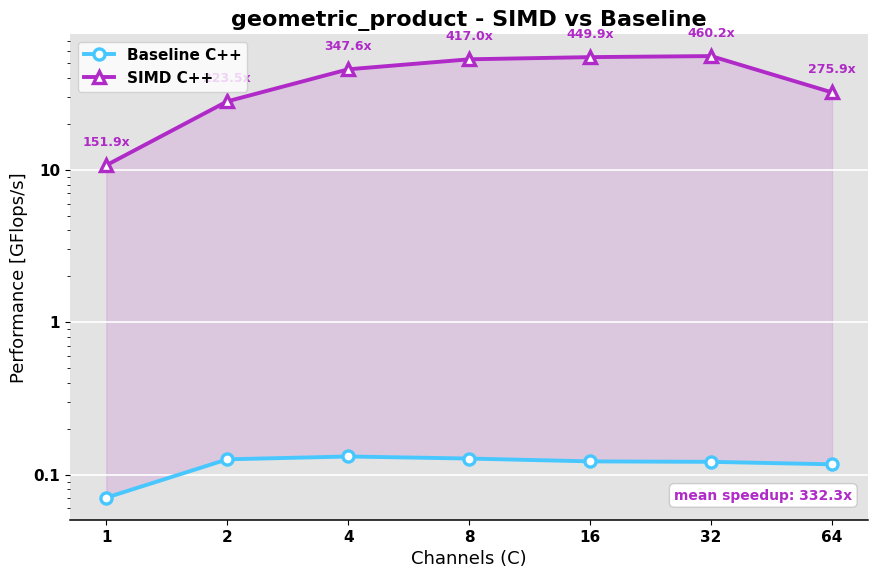

Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/simd_vs_baseline/simd_vs_baseline_performance_scaler_gated_gelu.png


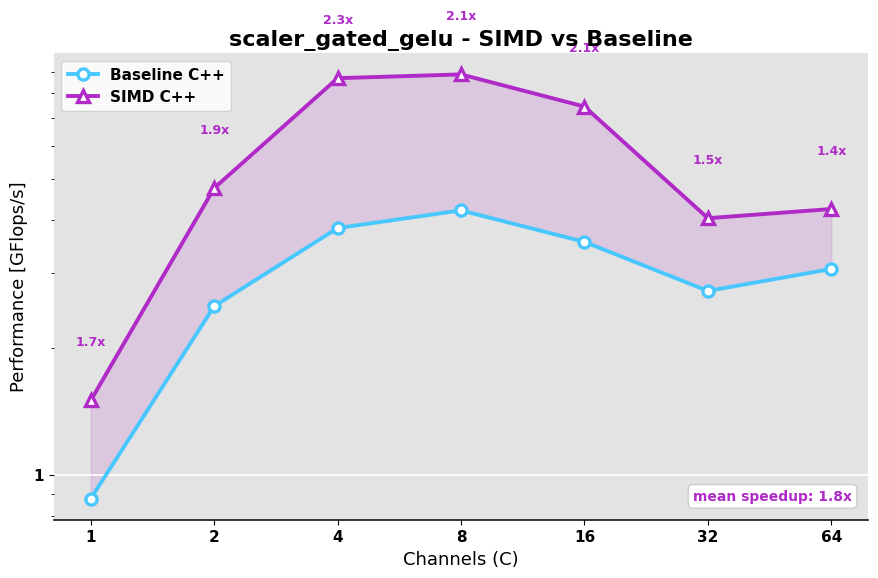

In [166]:
def plot_kernel_simd_vs_baseline(kernel="geometric_product"):
    part = baseline_vs_simd[baseline_vs_simd["kernel"] == kernel].sort_values("n")
    if part.empty:
        print(f"No SIMD-vs-baseline data for {kernel}")
        return

    fig, ax = plt.subplots(figsize=(9, 6))
    base_color = COLORS["Baseline C++"]
    simd_color = COLORS["SIMD C++"]

    ax.plot(part["n"], part["Baseline C++"], marker="o", markersize=8, linewidth=2.8,
            color=base_color, markerfacecolor="white", markeredgewidth=2.4, label="Baseline C++")
    ax.plot(part["n"], part["SIMD C++"], marker="^", markersize=9, linewidth=2.8,
            color=simd_color, markerfacecolor="white", markeredgewidth=2.4, label="SIMD C++")
    ax.fill_between(part["n"], part["Baseline C++"], part["SIMD C++"], color=simd_color, alpha=0.14)

    for _, row in part.iterrows():
        ax.text(row["n"], row["SIMD C++"] * 1.35, f"{row['speedup']:.1f}x",
                color=simd_color, fontsize=9, ha="center")

    ax.text(0.98, 0.05, f"mean speedup: {part['speedup'].mean():.1f}x", transform=ax.transAxes,
            ha="right", va="center", color=simd_color,
            bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.35"))
    ax.set_title(f"{kernel} - SIMD vs Baseline")
    ax.set_xlabel("Channels (C)")
    ax.set_ylabel("Performance [GFlops/s]")
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(sorted(part["n"].unique()))
    ax.set_xticklabels([str(x) for x in sorted(part["n"].unique())])
    ax.yaxis.set_major_formatter(FuncFormatter(perf_formatter))
    setup_axis(ax)
    ax.legend(loc="upper left")
    fig.tight_layout(pad=1.5)
    save_baseline_fig(fig, f"simd_vs_baseline_performance_{kernel}.png")
    plt.show()

for kernel in sorted(baseline_vs_simd["kernel"].unique()):
    plot_kernel_simd_vs_baseline(kernel)


### Top-2 speedups: SIMD vs Baseline

The two kernels with the largest mean speedup from `Baseline C++` to `SIMD C++`.


Saved: /Users/omarabdesslem/Documents/Cours/Master/M.1/2nd Sem/Labs/Advanced Systems Lab (ASL)/Project/team80/Results/timing_results/Plots/comparison_plots/M1/simd_vs_baseline/top_2_speedup_baseline_cpp_vs_simd_cpp_performance.png


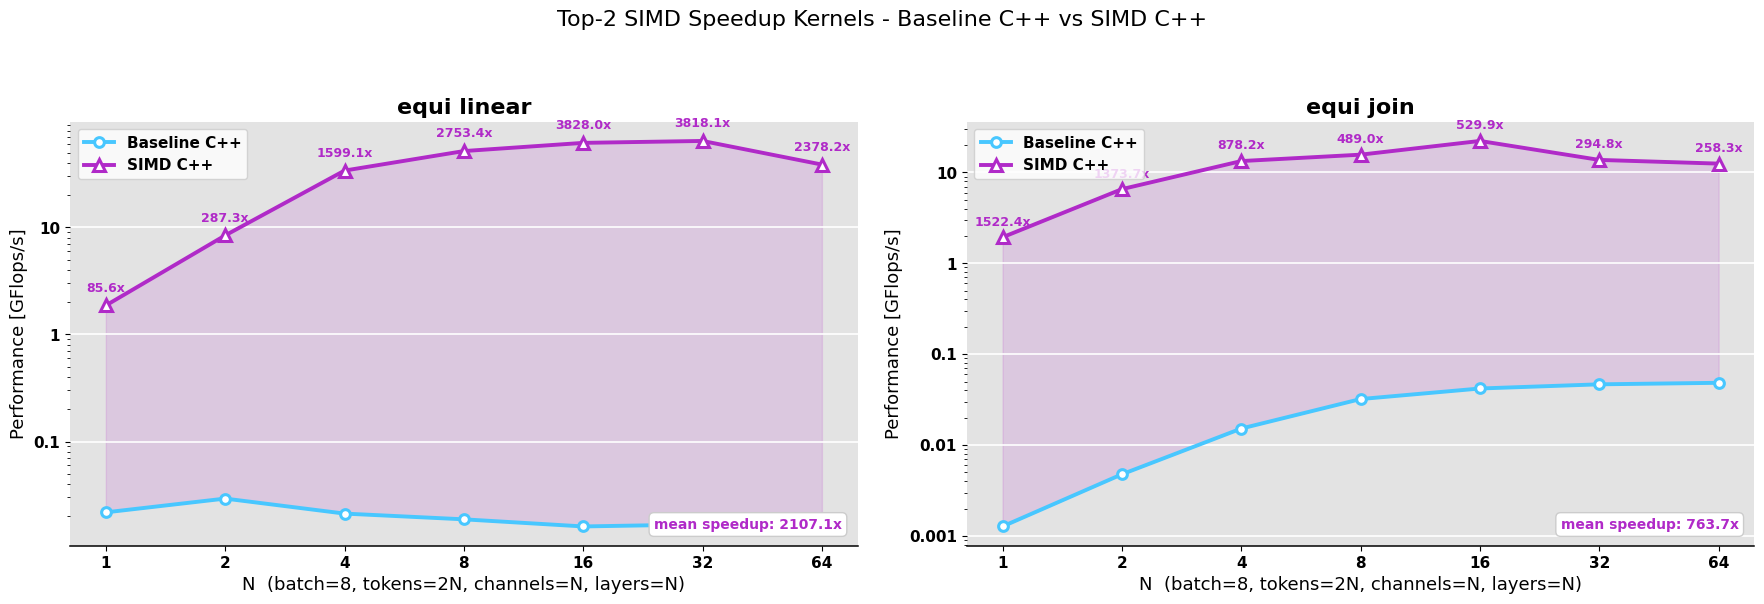

In [167]:
def plot_top2_simd_vs_baseline():
    top_kernels = (
        baseline_vs_simd.groupby("kernel")["speedup"]
        .mean()
        .sort_values(ascending=False)
        .head(2)
        .index
        .tolist()
    )
    if not top_kernels:
        print("No kernels available for top-2 SIMD-vs-baseline plot")
        return

    fig, axes = plt.subplots(1, len(top_kernels), figsize=(9 * len(top_kernels), 6), squeeze=False)
    fig.suptitle("Top-2 SIMD Speedup Kernels - Baseline C++ vs SIMD C++", fontsize=16, y=1.02)

    for ax, kernel in zip(axes[0], top_kernels):
        part = baseline_vs_simd[baseline_vs_simd["kernel"] == kernel].sort_values("n")
        base_color = COLORS["Baseline C++"]
        simd_color = COLORS["SIMD C++"]

        ax.plot(part["n"], part["Baseline C++"], marker="o", markersize=7, linewidth=2.8,
                color=base_color, markerfacecolor="white", markeredgewidth=2.2, label="Baseline C++")
        ax.plot(part["n"], part["SIMD C++"], marker="^", markersize=8, linewidth=2.8,
                color=simd_color, markerfacecolor="white", markeredgewidth=2.2, label="SIMD C++")
        ax.fill_between(part["n"], part["Baseline C++"], part["SIMD C++"], color=simd_color, alpha=0.14)

        for _, row in part.iterrows():
            ax.text(row["n"], row["SIMD C++"] * 1.35, f"{row['speedup']:.1f}x",
                    color=simd_color, fontsize=9, ha="center")

        ax.text(0.98, 0.05, f"mean speedup: {part['speedup'].mean():.1f}x", transform=ax.transAxes,
                ha="right", va="center", color=simd_color,
                bbox=dict(facecolor="white", edgecolor="#cccccc", boxstyle="round,pad=0.35"))
        ax.set_title(kernel.replace("_", " "))
        ax.set_xlabel("N  (batch=8, tokens=2N, channels=N, layers=N)")
        ax.set_ylabel("Performance [GFlops/s]")
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(sorted(part["n"].unique()))
        ax.set_xticklabels([str(x) for x in sorted(part["n"].unique())])
        ax.yaxis.set_major_formatter(FuncFormatter(perf_formatter))
        setup_axis(ax)
        ax.legend(loc="upper left")

    fig.tight_layout(pad=2.0)
    save_baseline_fig(fig, "top_2_speedup_baseline_cpp_vs_simd_cpp_performance.png")
    plt.show()

plot_top2_simd_vs_baseline()


## Save combined tables


In [168]:
# Loaded intermediate CSV exports are intentionally not written from this notebook.
